# **TECH CHALLENGE 3** — Análise Epidemiológica PNAD COVID-19

**Sintomas, Infecção e Condição Socioeconômica**

*Análise contratada por hospital privado de alta complexidade para subsidiar planejamento de resposta a novos surtos — com base nos microdados da PNAD COVID-19 (IBGE, 2020)*

Autores: André Pintor (RM 367388) · Marconi Silva (RM 368016) · Pedro Lucena (RM 367572)

**Turma:** 11DTAT | **Pós-Tech Data Analytics — POSTECH FIAP** | Abril 2026

# 0. Setup — Preparação do Ambiente

In [1]:
import os
# Importação das Bibliotecas Necessárias
import gdown
import pandas as pd
import geopandas as gpd

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings

warnings.filterwarnings('ignore')

# Depreciado: usa o tema do Einstein agora
# plt.rcParams['figure.figsize'] = (12, 5)
# plt.rcParams['font.size'] = 11

os.makedirs("graficos", exist_ok=True)
print("Pasta graficos/ pronta.")

Pasta graficos/ pronta.


In [2]:
# Importação dos Arquivos .V2

# Simplificando os IDs dos arquivos no Google Drive
dim_estratos = "1Nl5hEA60EL8DbfP8NPZ2byBLpX7vP5BJ"
dim_domicilios = "1R3lsfblLllUDlNaW1C1_TEzNusqogKxK"
dim_moradores = "13TkAWOiCgH1QgKH028MIj-HNOuS0GSC9"
dim_saude = "1pRe6EbxikgUe85zBaJjZCA-vZBWHi7Op"
dim_trabalho = "19HDCYkPa67Zm5oFkNTH-PCCaOkEMIvFt"

pesquisa_traduzida = "1emYQbIIh139CgY6z9O4W5H3G2bnBiGfb"
fact_domicilios = "1UJHZRJvuQh9GMebL2NkHjilATX5Y0ZX1"
fact_trabalho_renda = "1OLq5ApBKlAsgM2DGLV5NI5ZnOK0bkuR2"
fact_covid = "14XkC3rzTQoDmLzTHUlQPtr84l0-VU1U5"

tema_einstein = "1gqH1bOhj6HO0Wnk-zXtLxMme49Vve8PG"

# Dicionário com IDs simplificados e nomes locais para os arquivos CSV
arquivos = {
    dim_estratos : "dim_estratos.geojson",
    dim_domicilios : "dim_domicilios.csv",
    dim_moradores : "dim_moradores.csv",
    dim_saude : "dim_saude.csv",
    dim_trabalho : "dim_trabalho.csv",
    tema_einstein : "einstein_theme.py",
    }

# Dicionário de Parquets (Pastas)
parquets = {
    pesquisa_traduzida: "pesquisa_traduzida",
    fact_domicilios: "fact_domicilios",
    fact_trabalho_renda: "fact_trabalho_renda",
    fact_covid: "fact_covid",

}

print("\nBaixando arquivos CSV")
for file_id, nome_arquivo in arquivos.items():
    url = f"https://drive.google.com/uc?id={file_id}"
    r = gdown.download(url, nome_arquivo, quiet=False)

print("\nBaixando pastas Parquet...")
for folder_id, nome_dir in parquets.items():
    print(f"Baixando pasta: {nome_dir}")
    gdown.download_folder(id=folder_id, output=nome_dir, quiet=False)


Baixando arquivos CSV


Downloading...
From: https://drive.google.com/uc?id=1Nl5hEA60EL8DbfP8NPZ2byBLpX7vP5BJ
To: /content/dim_estratos.geojson
100%|██████████| 99.0M/99.0M [00:02<00:00, 36.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1R3lsfblLllUDlNaW1C1_TEzNusqogKxK
To: /content/dim_domicilios.csv
100%|██████████| 12.7M/12.7M [00:00<00:00, 39.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=13TkAWOiCgH1QgKH028MIj-HNOuS0GSC9
To: /content/dim_moradores.csv
100%|██████████| 61.0M/61.0M [00:00<00:00, 104MB/s]
Downloading...
From: https://drive.google.com/uc?id=1pRe6EbxikgUe85zBaJjZCA-vZBWHi7Op
To: /content/dim_saude.csv
100%|██████████| 45.5M/45.5M [00:00<00:00, 75.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=19HDCYkPa67Zm5oFkNTH-PCCaOkEMIvFt
To: /content/dim_trabalho.csv
100%|██████████| 68.6M/68.6M [00:00<00:00, 94.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1gqH1bOhj6HO0Wnk-zXtLxMme49Vve8PG
From (redirected): https://drive.google.com/uc?id=1gqH1


Baixando pastas Parquet...
Baixando pasta: pesquisa_traduzida
Processing file 1hPylsbDIXimwKv3QNKqjM1pJQsO9QpjY _SUCCESS
Processing file 139Ne4Ejg_YHqUDuiITwTfDUeFHgrg2D0 ._SUCCESS.crc
Processing file 1LwPpV1bIT0mwURrdLP8COLq5ARYlZeIr .part-00000-38e27e40-a192-457b-aa09-542b0df52d10-c000.snappy.parquet.crc
Processing file 1T9-DwVZsyuJF0PHAG2oeuhLRlIBgV4M5 part-00000-38e27e40-a192-457b-aa09-542b0df52d10-c000.snappy.parquet


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1hPylsbDIXimwKv3QNKqjM1pJQsO9QpjY
To: /content/pesquisa_traduzida/_SUCCESS
0.00B [00:00, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=139Ne4Ejg_YHqUDuiITwTfDUeFHgrg2D0
To: /content/pesquisa_traduzida/._SUCCESS.crc
100%|██████████| 8.00/8.00 [00:00<00:00, 24.5kB/s]
Downloading...
From: https://drive.google.com/uc?id=1LwPpV1bIT0mwURrdLP8COLq5ARYlZeIr
To: /content/pesquisa_traduzida/.part-00000-38e27e40-a192-457b-aa09-542b0df52d10-c000.snappy.parquet.crc
100%|██████████| 666k/666k [00:00<00:00, 6.32MB/s]
Downloading...
From: https://drive.google.com/uc?id=1T9-DwVZsyuJF0PHAG2oeuhLRlIBgV4M5
To: /content/pesquisa_traduzida/part-00000-38e27e40-a192-457b-aa09-542b0df52d10-c000.snappy.parquet
100%|██████████| 85.2M/85.2M [00:01<00:00, 64.8MB/s]
Download completed
Retrieving folder contents


Baixando pasta: fact_domicilios
Processing file 1rpV7yXvAvoBDwL3Ig2i-E5xQRKV9PYSx _SUCCESS
Processing file 1lM6aLOf0MfoPZnBhEM2X0O2GRCuP8JXb ._SUCCESS.crc
Processing file 16j4TBk5BtU_9IMJbtDM963fDv86GxHbS .part-00000-b4c0d3a1-9b5c-45ed-83a5-b0b4b0ac788b-c000.snappy.parquet.crc
Processing file 1sltKRyVxEASMqpGonHBddUnxGVYzyYFt part-00000-b4c0d3a1-9b5c-45ed-83a5-b0b4b0ac788b-c000.snappy.parquet


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1rpV7yXvAvoBDwL3Ig2i-E5xQRKV9PYSx
To: /content/fact_domicilios/_SUCCESS
0.00B [00:00, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=1lM6aLOf0MfoPZnBhEM2X0O2GRCuP8JXb
To: /content/fact_domicilios/._SUCCESS.crc
100%|██████████| 8.00/8.00 [00:00<00:00, 16.7kB/s]
Downloading...
From: https://drive.google.com/uc?id=16j4TBk5BtU_9IMJbtDM963fDv86GxHbS
To: /content/fact_domicilios/.part-00000-b4c0d3a1-9b5c-45ed-83a5-b0b4b0ac788b-c000.snappy.parquet.crc
100%|██████████| 126k/126k [00:00<00:00, 3.05MB/s]
Downloading...
From: https://drive.google.com/uc?id=1sltKRyVxEASMqpGonHBddUnxGVYzyYFt
To: /content/fact_domicilios/part-00000-b4c0d3a1-9b5c-45ed-83a5-b0b4b0ac788b-c000.snappy.parquet
100%|██████████| 16.1M/16.1M [00:00<00:00, 48.3MB/s]
Download completed
Retrieving folder contents


Baixando pasta: fact_trabalho_renda
Processing file 1VjdeeTh9glHR4aj7Sl4T5nKeA0tUZzXs _SUCCESS
Processing file 1wvAZHQI2MqZmc0lLldzSEv1ek46k7E4_ ._SUCCESS.crc
Processing file 1dESrZN7pWoDi7qjyUXYgVdmgOhtuslij .part-00000-dbf70841-48af-4e3c-a1be-6f4caa57d3a2-c000.snappy.parquet.crc
Processing file 1o56XdUSeyUDEH3VooGuP7C4ZlTNSiPJ3 part-00000-dbf70841-48af-4e3c-a1be-6f4caa57d3a2-c000.snappy.parquet


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1VjdeeTh9glHR4aj7Sl4T5nKeA0tUZzXs
To: /content/fact_trabalho_renda/_SUCCESS
0.00B [00:00, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=1wvAZHQI2MqZmc0lLldzSEv1ek46k7E4_
To: /content/fact_trabalho_renda/._SUCCESS.crc
100%|██████████| 8.00/8.00 [00:00<00:00, 14.3kB/s]
Downloading...
From: https://drive.google.com/uc?id=1dESrZN7pWoDi7qjyUXYgVdmgOhtuslij
To: /content/fact_trabalho_renda/.part-00000-dbf70841-48af-4e3c-a1be-6f4caa57d3a2-c000.snappy.parquet.crc
100%|██████████| 402k/402k [00:00<00:00, 4.88MB/s]
Downloading...
From: https://drive.google.com/uc?id=1o56XdUSeyUDEH3VooGuP7C4ZlTNSiPJ3
To: /content/fact_trabalho_renda/part-00000-dbf70841-48af-4e3c-a1be-6f4caa57d3a2-c000.snappy.parquet
100%|██████████| 51.5M/51.5M [00:01<00:00, 38.1MB/s]
Download completed
Retrieving folder contents


Baixando pasta: fact_covid
Processing file 1AeP1q5TH7v0NwUfqZpNSjKpCbCknjg_d _SUCCESS
Processing file 1MMyw6cZBrS_MpJDYNTpsqXG74mq9jx7m ._SUCCESS.crc
Processing file 1pnisoS_LCCyD_iVSTnR55XptVbSvyU77 .part-00000-156a307d-d95d-41c3-95df-d2ef3e836db2-c000.snappy.parquet.crc
Processing file 10ueSl-Na3ccEs2m4jAHNOQn08bQqwZKV part-00000-156a307d-d95d-41c3-95df-d2ef3e836db2-c000.snappy.parquet


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1AeP1q5TH7v0NwUfqZpNSjKpCbCknjg_d
To: /content/fact_covid/_SUCCESS
0.00B [00:00, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=1MMyw6cZBrS_MpJDYNTpsqXG74mq9jx7m
To: /content/fact_covid/._SUCCESS.crc
100%|██████████| 8.00/8.00 [00:00<00:00, 15.4kB/s]
Downloading...
From: https://drive.google.com/uc?id=1pnisoS_LCCyD_iVSTnR55XptVbSvyU77
To: /content/fact_covid/.part-00000-156a307d-d95d-41c3-95df-d2ef3e836db2-c000.snappy.parquet.crc
100%|██████████| 365k/365k [00:00<00:00, 4.74MB/s]
Downloading...
From: https://drive.google.com/uc?id=10ueSl-Na3ccEs2m4jAHNOQn08bQqwZKV
To: /content/fact_covid/part-00000-156a307d-d95d-41c3-95df-d2ef3e836db2-c000.snappy.parquet
100%|██████████| 46.7M/46.7M [00:01<00:00, 37.9MB/s]
Download completed


In [3]:
# Inicialização da sessão Spark
spark = SparkSession.builder \
    .appName("TechChallenge3") \
    .config("spark.sql.warehouse.dir", "/content/spark-warehouse") \
    .getOrCreate()

# Verificação da Sessão
print(f"Sessão Spark iniciada: {spark.version}")

Sessão Spark iniciada: 4.0.2


In [4]:
from einstein_theme import apply_einstein_theme, PALETA, CMAP_EINSTEIN
apply_einstein_theme()

# Constantes globais
IGNORADOS = ['Ignorado', 'N\u00e3o sabe']
PESO      = 'Peso do morador'
MESES     = {5:'Mai', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov'}

COR_POS  = PALETA["primario"]
COR_NEG  = PALETA["cinza_40"]
DPI_PNG  = 150


In [5]:
def pct_pond_spark(fact_df, coluna, valor='Sim'):
      """
      Calcula que % da população respondeu `valor` a uma pergunta.

      A amostra do IBGE não é aleatória simples — alguns grupos são
      sobre-representados, outros sub-representados. Para corrigir isso,
      cada pessoa tem um peso (Peso do morador) que indica quantas pessoas
      reais ela representa. Em vez de contar respostas, somamos pesos:
      se 1000 pessoas com peso médio 400 responderam 'Sim', isso representa
      400.000 brasileiros.

      Duas categorias de linhas são excluídas do cálculo:
      • null       → pessoa não chegou à pergunta por roteamento do questionário.
                     Incluir no denominador subestimaria a proporção real.
      • 'Ignorado' / 'Não sabe' → resposta inválida, não representa Sim nem Não.

      Parâmetros
      ----------
      fact_df : Spark DataFrame
          Tabela fato já carregada (spark_fact_covid ou spark_fact_trabalho_renda).
      coluna : str
          Nome da coluna categórica a avaliar.
      valor : str, padrão 'Sim'
          Categoria considerada positiva no cálculo do numerador.

      Retorna
      -------
      float
          Proporção entre 0 e 100, ou nan se não houver nenhuma linha válida.
      """
      # Remove linhas inválidas antes de qualquer cálculo.
      # isNotNull()        → descarta null (pessoa não chegou à pergunta por roteamento)
      # ~isin(IGNORADOS)   → o ~ é NOT; descarta 'Ignorado' e 'Não sabe'
      # & une as duas condições: ambas precisam ser verdadeiras para a linha passar
      sub = fact_df.filter(
          col(coluna).isNotNull() & ~col(coluna).isin(IGNORADOS)
      )

      # .agg() faz múltiplas agregações em uma única passagem pelo DataFrame Spark
      row = sub.agg(

          # when(condição, valor_se_true).otherwise(valor_se_false) → IF/ELSE por linha
          # Se respondeu `valor` (ex: 'Sim') → contribui com o peso da pessoa
          # Se respondeu outra coisa válida (ex: 'Não') → contribui com 0
          # sum() soma tudo → peso total de quem respondeu o valor procurado
          sum(when(col(coluna) == valor, col(PESO)).otherwise(0)).alias('num'),

          # Soma os pesos de todas as linhas válidas (após o filter acima)
          # .alias() renomeia a coluna resultante para acessar pelo nome depois
          sum(PESO).alias('den')

      ).collect()[0]  # .collect() traz o resultado Spark para o Python local
                      # [0] pega a única linha retornada (objeto Row)

      # num/den * 100 = proporção em %
      # 'if row["den"]' evita ZeroDivisionError se não houver nenhuma linha válida
      return (row['num'] / row['den'] * 100) if row['den'] else float('nan')


def pct_pond_por_mes_spark(fact_df, coluna, valor='Sim'):
      """
      Mesma lógica de pct_pond_spark, calculada separadamente para cada mês.

      Cada mês da pesquisa é uma rodada independente com seus próprios pesos.
      Por isso a proporção é calculada dentro de cada mês — nunca sobre o
      total empilhado de todos os meses, o que misturaria pesos incomparáveis
      entre rodadas.

      Parâmetros
      ----------
      fact_df : Spark DataFrame
          Tabela fato já carregada (spark_fact_covid ou spark_fact_trabalho_renda).
      coluna : str
          Nome da coluna categórica a avaliar.
      valor : str, padrão 'Sim'
          Categoria considerada positiva no cálculo do numerador.

      Retorna
      -------
      pandas.Series
          Índice = nome abreviado do mês (ex: 'Set', 'Out', 'Nov').
          Valores = proporção ponderada em %, pronta para plot.
      """
      # Mesma exclusão de nulls e ignorados que pct_pond_spark
      sub = fact_df.filter(
          col(coluna).isNotNull() & ~col(coluna).isin(IGNORADOS)
      )

      result = (
          sub
          # Cria coluna 'mes' extraindo o número do mês da coluna 'data' (ex: 9, 10, 11)
          .withColumn('mes', month('data'))

          # Agrupa por mês — cada grupo recebe seu próprio numerador e denominador
          .groupBy('mes')
          .agg(
              # Mesma fórmula de pct_pond_spark, calculada dentro de cada mês.
              # Spark faz tudo no cluster; só o resultado (~7 linhas) vem para o Python
              (sum(when(col(coluna) == valor, col(PESO)).otherwise(0)) /
               sum(PESO) * 100).alias('pct')
          )
          .orderBy('mes')

          # Traz o resultado pequeno (~7 linhas) para Pandas para indexar e plotar
          .toPandas()
      )

      # Substitui o número do mês pelo nome abreviado usando o dict MESES {9:'Set', ...}
      result['mes_nome'] = result['mes'].map(MESES)

      # Retorna Series indexada pelo nome do mês — pronta para ax.plot() ou ax.bar()
      return result.set_index('mes_nome')['pct']


def pop_estimada_por_mes_spark(fact_df):
      """
      Soma os pesos de todas as pessoas entrevistadas em cada mês.

      Cada pessoa na amostra tem um peso (Peso do morador) que indica quantas
      pessoas reais ela representa na população. Somar esses pesos dentro de
      um mês dá o total de brasileiros que aquela rodada pretende representar.

      ⚠️   Não é a população absoluta do Brasil. O IBGE recalibra os pesos
      a cada rodada para ajustá-los a totais de referência externos (Censo,
      PNAD Contínua). Por isso os totais variam entre meses e não devem ser
      comparados entre si — use apenas para ter noção do tamanho relativo
      de cada rodada, não para comparar crescimento populacional.

      Parâmetros
      ----------
      fact_df : Spark DataFrame
          Tabela fato já carregada (spark_fact_covid ou spark_fact_trabalho_renda).

      Retorna
      -------
      pandas.Series
          Índice = nome abreviado do mês. Valores = soma dos pesos.
      """
      return (
          fact_df
          # Extrai número do mês da coluna 'data'
          .withColumn('mes', month('data'))

          # Soma todos os pesos dentro de cada mês
          .groupBy('mes').agg(sum(PESO).alias('pop'))

          .orderBy('mes')

          # Traz para Pandas (~7 linhas) para indexar pelo nome do mês
          .toPandas()

          # Cria coluna com nome do mês a partir do número
          .assign(mes_nome=lambda d: d['mes'].map(MESES))

          # Define mes_nome como índice e retorna só a coluna de valores
          .set_index('mes_nome')['pop']
      )


def abrev_escolaridade(s):
    mapa = {
        'Sem instru\u00e7\u00e3o e menos de 1 ano de estudo': 'Sem instru\u00e7\u00e3o',
        'Ensino fundamental incompleto ou equivalente': 'Fund. incompleto',
        'Ensino fundamental completo ou equivalente': 'Fund. completo',
        'Ensino m\u00e9dio incompleto ou equivalente': 'M\u00e9dio incompleto',
        'Ensino m\u00e9dio completo ou equivalente': 'M\u00e9dio completo',
        'Ensino superior incompleto ou equivalente': 'Superior incompleto',
        'Ensino superior completo': 'Superior completo',
        'P\u00f3s-gradua\u00e7\u00e3o': 'P\u00f3s-gradua\u00e7\u00e3o',
    }
    return mapa.get(s, s[:22] + '\u2026' if len(s) > 22 else s)

def abrev_trabalho(s):
    mapa = {
        'Empregado do setor privado': 'Emp. privado',
        'Empregado do setor p\u00fablico': 'Emp. p\u00fablico',
        'Empregador': 'Empregador',
        'Trabalhador por conta pr\u00f3pria': 'Conta pr\u00f3pria',
        'Trabalhador familiar auxiliar n\u00e3o remunerado': 'Familiar n. rem.',
        'Militar e servidor estatut\u00e1rio': 'Militar/Estatut.',
        'Sem v\u00ednculo': 'Sem v\u00ednculo',
    }
    return mapa.get(s, s[:18] + '\u2026' if len(s) > 18 else s)


In [6]:
# Importação das tabelas-dimensão
dim_estratos = gpd.read_file("dim_estratos.geojson")
dim_domicilios = pd.read_csv("dim_domicilios.csv", sep=';')
dim_moradores = pd.read_csv("dim_moradores.csv", sep=';')
dim_saude = pd.read_csv("dim_saude.csv", sep=';')
dim_trabalho = pd.read_csv("dim_trabalho.csv", sep=';')

In [7]:
# Importação das tabelas-fato com PySpark (mais eficiente para consultas)
spark_fact_domicilios = spark.read.option("header", True).parquet('fact_domicilios')
spark_fact_trabalho_renda = spark.read.option("header", True).parquet('fact_trabalho_renda')
spark_fact_covid = spark.read.option("header", True).parquet('fact_covid')

# 1 — Análise de Sintomas, Infecção e Condição Socioeconômica

**Perguntas respondidas nesta análise:**
1. Há correlação entre apresentar sintomas e estar infectado pelo COVID-19?
2. O nível de exposição ao vírus varia com a condição socioeconômica?
3. Domicílios beneficiários do auxílio emergencial tiveram exposição diferente ao COVID-19?

**Dados:** tabelas V2 — camada Gold. Proporções ponderadas por `morador_peso` (pessoas) e `domicílio_peso` (domicílios).

> **Contexto do contratante:** o hospital é uma instituição privada de alta complexidade, com perfil de pacientes concentrado nas faixas de maior renda e escolaridade. Essa característica é relevante para a interpretação das Seções 2 e 3: grupos de maior capacidade de isolamento foram infectados com atraso — e entender esse atraso é a chave para o planejamento de demanda do hospital.

---
## 1.1 — Correlação entre Sintomas e Resultado de Teste

**Pergunta:** apresentar sintomas na semana da entrevista aumenta a probabilidade de teste positivo para COVID-19?

**Metodologia:**
- Base: entrevistados que realizaram ao menos um dos três testes (SWAB, furo no dedo, punção venosa).
- Resultado positivo: qualquer teste com resultado 'Positivo'.
- Pesos: `morador_peso`. Diarreia excluída (Nota 5 IBGE).
- **Dois controles:** plano de saúde (viés diagnóstico) e doença respiratória crônica (confundimento).

In [45]:
# ── Seção 1: Correlação sintomas × resultado — cálculos ─────────────────────

SINTOMAS_V2 = {
    'sintomas_febre':                     'Febre',
    'sintomas_tosse':                     'Tosse',
    'sintomas_dor_de_garganta':           'Dor garganta',
    'sintomas_dificuldade_para_respirar': 'Dific. respirar',
    'sintomas_dor_de_cabe\u00e7a':         'Dor cabe\u00e7a',
    'sintomas_dor_no_peito':              'Dor peito',
    'sintomas_n\u00e1usea':                'N\u00e1usea',
    'sintomas_nariz_escorrendo':          'Coriza',
    'sintomas_fadiga':                    'Fadiga',
    'sintomas_dor_nos_olhos':             'Dor olhos',
    'sintomas_perda_de_olfato':           'Perda olfato',
    'sintomas_dor_muscular':              'Dor muscular',
}

PESO_V2  = 'morador_peso'
COL_SWAB = 'exames_resultado_SWAB'
COL_DEDO = 'exames_resultado_furo_no_dedo'
COL_VEIA = 'exames_resultado_pun\u00e7\u00e3o_venosa'
COL_RESP = 'sintomas_dificuldade_para_respirar'

# Base: testados
cond_fez = col(COL_SWAB).isNotNull() | col(COL_DEDO).isNotNull() | col(COL_VEIA).isNotNull()
cond_pos = (col(COL_SWAB) == 'Positivo') | (col(COL_DEDO) == 'Positivo') | (col(COL_VEIA) == 'Positivo')
spark_testados = (
    spark_fact_covid.filter(cond_fez)
    .withColumn('resultado', when(cond_pos, 'Positivo').otherwise('Negativo/Inc.'))
)

# Flag algum sintoma (excl. diarreia)
cond_algum = col(list(SINTOMAS_V2.keys())[0]) == 'Sim'
for c in list(SINTOMAS_V2.keys())[1:]:
    cond_algum = cond_algum | (col(c) == 'Sim')

# Join dim_saude
cols_saude = ['id_morador', 'tem_plano_de_sa\u00fade', 'doen\u00e7as_cr\u00f4nicas_doen\u00e7a_respirat\u00f3ria']
df_saude_cast = dim_saude[cols_saude].copy()
for c in cols_saude[1:]:
    df_saude_cast[c] = df_saude_cast[c].astype('boolean').astype(str)
spark_saude = spark.createDataFrame(df_saude_cast)
spark_t = spark_testados.join(spark_saude, on='id_morador', how='left')

# Funções
def pct_pos(df, cond_sint, valor_sint):
    sub = df.filter(col(cond_sint) == valor_sint)
    total = sub.agg(sum(PESO_V2)).collect()[0][0] or 0
    pos   = sub.filter(col('resultado') == 'Positivo').agg(sum(PESO_V2)).collect()[0][0] or 0
    return (pos / total * 100) if total else 0

def baseline(df, filtro_col, filtro_val):
    sub = df.filter(col(filtro_col) == filtro_val).filter(~cond_algum)
    total = sub.agg(sum(PESO_V2)).collect()[0][0] or 0
    pos   = sub.filter(col('resultado') == 'Positivo').agg(sum(PESO_V2)).collect()[0][0] or 0
    return (pos / total * 100) if total else 0

# 5a. Distribuição com/sem sintoma
ct = (
    spark_t.withColumn('sintoma', when(cond_algum, 'Com sintoma').otherwise('Sem sintoma'))
    .groupBy('resultado', 'sintoma').agg(sum(PESO_V2).alias('w'))
    .toPandas().pivot(index='resultado', columns='sintoma', values='w').fillna(0)
)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# 5b. Plano de saúde
def pct_pos_com_sint(df, plano_val):
    sub = df.filter(col('tem_plano_de_sa\u00fade') == plano_val).filter(cond_algum)
    total = sub.agg(sum(PESO_V2)).collect()[0][0] or 0
    pos   = sub.filter(col('resultado') == 'Positivo').agg(sum(PESO_V2)).collect()[0][0] or 0
    return (pos / total * 100) if total else 0

df_plano = pd.DataFrame({
    'Com sintoma': [pct_pos_com_sint(spark_t, 'True'),  pct_pos_com_sint(spark_t, 'False')],
    'Sem sintoma': [baseline(spark_t, 'tem_plano_de_sa\u00fade', 'True'),
                    baseline(spark_t, 'tem_plano_de_sa\u00fade', 'False')],
}, index=['Com plano', 'Sem plano'])

# 5c. Doença resp. crônica
df_cronica = pd.DataFrame({
    'Com sintoma': [
        pct_pos(spark_t.filter(col('doen\u00e7as_cr\u00f4nicas_doen\u00e7a_respirat\u00f3ria') == 'False')
                       .filter(col(COL_RESP).isNotNull()), COL_RESP, 'Sim'),
        pct_pos(spark_t.filter(col('doen\u00e7as_cr\u00f4nicas_doen\u00e7a_respirat\u00f3ria') == 'True')
                       .filter(col(COL_RESP).isNotNull()),  COL_RESP, 'Sim'),
    ],
    'Sem sintoma': [
        pct_pos(spark_t.filter(col('doen\u00e7as_cr\u00f4nicas_doen\u00e7a_respirat\u00f3ria') == 'False')
                       .filter(col(COL_RESP).isNotNull()), COL_RESP, 'N\u00e3o'),
        pct_pos(spark_t.filter(col('doen\u00e7as_cr\u00f4nicas_doen\u00e7a_respirat\u00f3ria') == 'True')
                       .filter(col(COL_RESP).isNotNull()),  COL_RESP, 'N\u00e3o'),
    ],
}, index=['Sem resp. cr\u00f4nica', 'Com resp. cr\u00f4nica'])

# 5d. Ranking por sintoma
spark_sem_cronica = spark_t.filter(col('doen\u00e7as_cr\u00f4nicas_doen\u00e7a_respirat\u00f3ria') == 'False')
rows = []
for col_sint, nome in SINTOMAS_V2.items():
    base = spark_sem_cronica.filter(col(col_sint).isNotNull())
    com  = pct_pos(base, col_sint, 'Sim')
    sem_ = pct_pos(base, col_sint, 'N\u00e3o')
    rows.append({'Sintoma': nome, 'COM': com, 'SEM': sem_, 'pp': com - sem_})
df_rank = pd.DataFrame(rows).set_index('Sintoma').sort_values('pp')


# Baseline geral (sem sintoma, todos os testados)
sub_geral = spark_t.filter(~cond_algum)
total_g = sub_geral.agg(sum(PESO_V2)).collect()[0][0]
pos_g   = sub_geral.filter(col('resultado') == 'Positivo').agg(sum(PESO_V2)).collect()[0][0]
print(f"Baseline geral (sem sintoma): {pos_g/total_g*100:.1f}%")

print("C\u00e1lculos Sec 1 conclu\u00eddos.")


Baseline geral (sem sintoma): 20.8%
Cálculos Sec 1 concluídos.


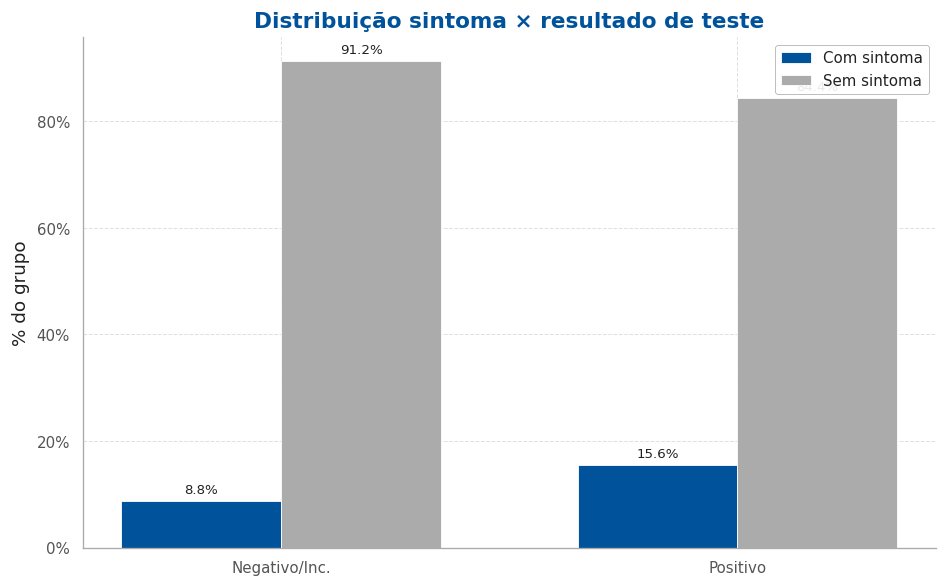

g1 salvo


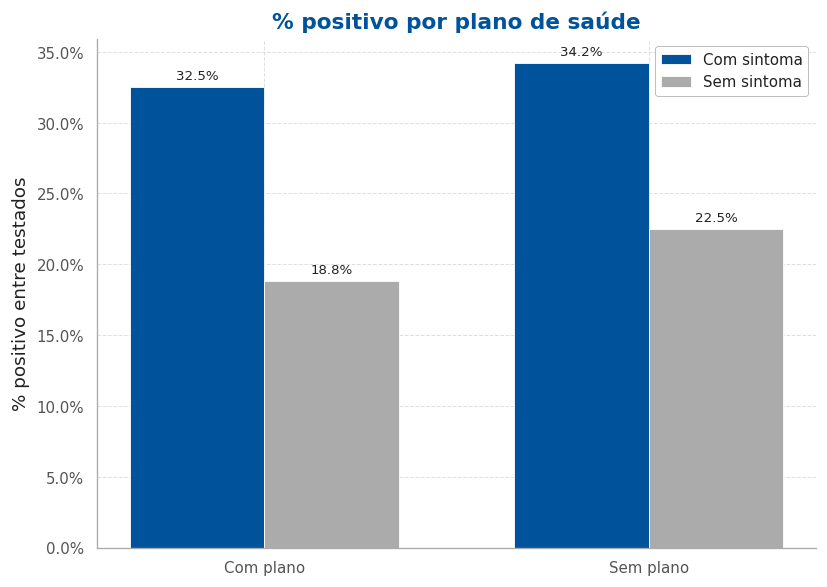

g2 salvo


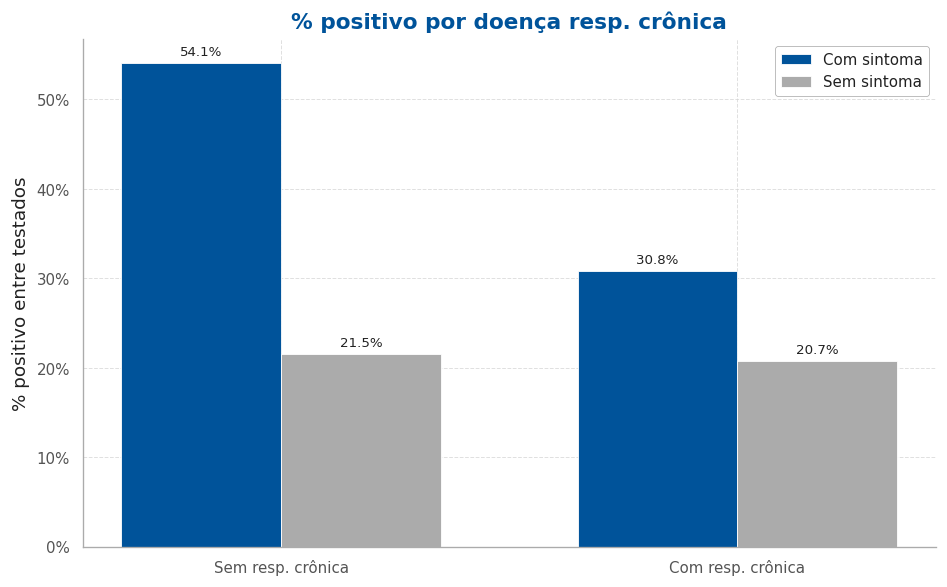

g3 salvo


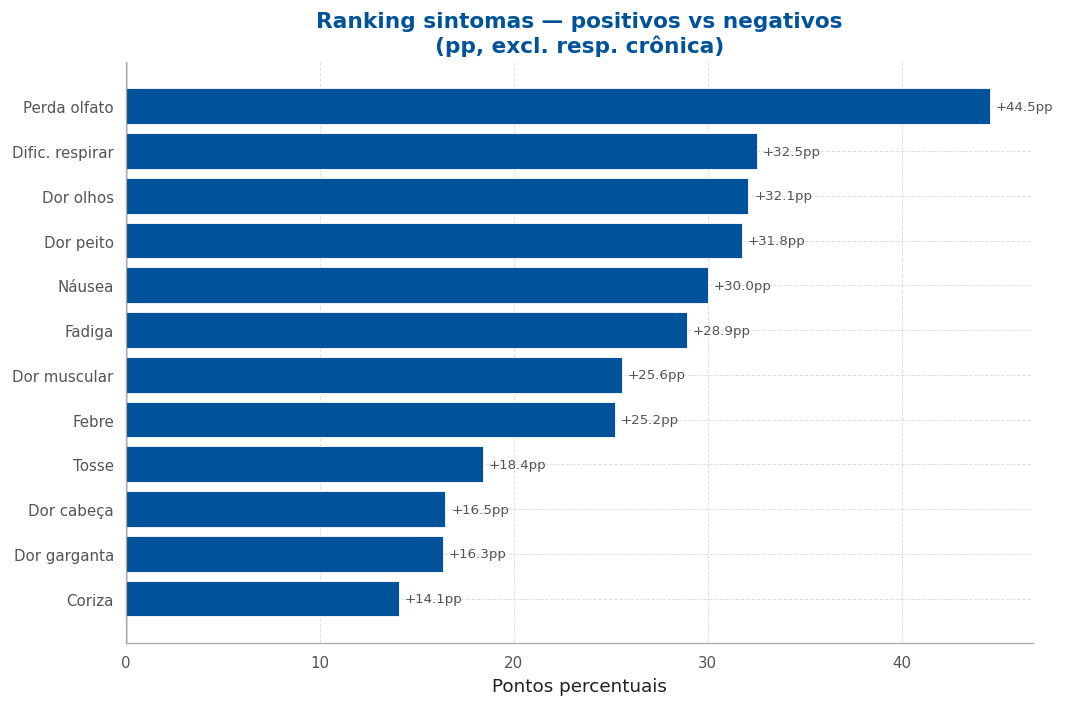

g4 salvo


In [9]:
# ── Gr\u00e1ficos Se\u00e7\u00e3o 1 — 4 PNGs individuais ─────────────────────────────────

def barras_grupo(ax, df, titulo, ylabel='% positivo entre testados'):
    x, w = range(len(df)), 0.35
    b1 = ax.bar([i - w/2 for i in x], df['Com sintoma'], w, label='Com sintoma', color=COR_POS)
    b2 = ax.bar([i + w/2 for i in x], df['Sem sintoma'], w, label='Sem sintoma', color=COR_NEG)
    ax.set_title(titulo)
    ax.set_ylabel(ylabel)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df.index.tolist())
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(loc='upper right')
    ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=8)
    ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=8)

# G1 — Distribui\u00e7\u00e3o sintoma × resultado
fig, ax = plt.subplots(figsize=(8, 5))
barras_grupo(ax, ct_pct,
             'Distribui\u00e7\u00e3o sintoma × resultado de teste',
             ylabel='% do grupo')
plt.tight_layout()
plt.savefig('graficos/g1_distribuicao_sintoma.png', dpi=DPI_PNG)
plt.show()
print("g1 salvo")

# G2 — Plano de sa\u00fade
fig, ax = plt.subplots(figsize=(7, 5))
barras_grupo(ax, df_plano, '% positivo por plano de sa\u00fade')
plt.tight_layout()
plt.savefig('graficos/g2_plano_saude.png', dpi=DPI_PNG)
plt.show()
print("g2 salvo")

# G3 — Doen\u00e7a resp. cr\u00f4nica
fig, ax = plt.subplots(figsize=(8, 5))
barras_grupo(ax, df_cronica, '% positivo por doen\u00e7a resp. cr\u00f4nica')
plt.tight_layout()
plt.savefig('graficos/g3_doenca_cronica.png', dpi=DPI_PNG)
plt.show()
print("g3 salvo")

# G4 — Ranking sintomas (pp)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(df_rank.index, df_rank['pp'], color=COR_POS)
ax.axvline(0, color=PALETA["cinza_90"], linewidth=0.8)
ax.set_title('Ranking sintomas — positivos vs negativos\n(pp, excl. resp. cr\u00f4nica)')
ax.set_xlabel('Pontos percentuais')
for i, v in enumerate(df_rank['pp']):
    ax.text(v + 0.3, i, f'+{v:.1f}pp', va='center', fontsize=8, color=PALETA["texto_leve"])
plt.tight_layout()
plt.savefig('graficos/g4_ranking_sintomas.png', dpi=DPI_PNG)
plt.show()
print("g4 salvo")


In [48]:
spark_fact_covid.join(
spark_saude.select('id_morador', 'tem_plano_de_saúde'),
on='id_morador', how='left'
).groupBy('tem_plano_de_saúde').agg(
(sum(when(
col('exames_resultado_SWAB').isNotNull() |
col('exames_resultado_furo_no_dedo').isNotNull() |
col('exames_resultado_punção_venosa').isNotNull(),
col(PESO_V2)).otherwise(0)) /
sum(PESO_V2) * 100
).alias('pct_testados')
).orderBy('tem_plano_de_saúde').show()


+------------------+------------------+
|tem_plano_de_saúde|      pct_testados|
+------------------+------------------+
|              <NA>|1.5374329623414806|
|             False| 5.325656375954348|
|              True| 11.72455350603803|
+------------------+------------------+



**Interpretação — Correlação entre sintomas e teste positivo**

---

**A correlação existe e o ranking é robusto.**

Entre os testados, positivos têm quase o dobro de sintomáticos (15,6% vs 8,8%). O gráfico de distribuição com/sem sintoma por resultado confirma a correlação de forma direta.

O dado complementar é o inverso: 84,4% dos positivos não reportaram sintoma na semana da entrevista. Isso não significa assintomáticos — o PNAD captura sintomas da semana corrente, enquanto o teste pode ter sido feito semanas antes. A janela temporal entre sintoma e teste é diferente, o que limita a leitura direta mas não invalida a análise.

---

**O ranking de sintomas é epidemiologicamente consistente.**

- **Perda de cheiro/sabor (+44pp)** — outlier absoluto. 65% de positividade entre quem reportou vs ~21% de baseline. Único sintoma sem equivalente em outras infecções respiratórias comuns — o sinal é confiável independente de qualquer estratificação.
- **Cluster intermediário (24–31pp):** fadiga, dor muscular, febre, náusea, dor no peito, dor nos olhos — sintomas sistêmicos de infecção viral severa.
- **Cluster baixo (13–17pp):** tosse, dor de cabeça, dor de garganta, coriza — inespecíficos, aparecem em qualquer resfriado.

Este padrão é o mesmo encontrado na literatura internacional de 2020.

---

**Controle 1 — Plano de saúde não explica o baseline alto.**

O baseline de ~21% positivo entre testados sem sintoma é alto demais para ser a população geral. A hipótese inicial era que quem tem plano testa por conveniência, inflando o baseline. O resultado foi o oposto: sem plano tem baseline maior (22,5% vs 18,8%). O acesso facilitado a teste não explica o baseline alto — a origem é outra (retomada na análise socioeconômica).

---

**Controle 2 — Doença respiratória crônica confunde o sinal de 'dificuldade respirar'.**

Entre portadores de asma ou DPOC, o diferencial de positividade para 'dificuldade respirar' cai de +32,5pp para +10,1pp. O sintoma estava sendo parcialmente consumido pela condição preexistente. Consequência: quando controlado pelas comorbidades, 'dificuldade respirar' sobe no ranking — e perda de cheiro/sabor se consolida como o único indicador sem confundimento identificável.

---
### 1.1.1 — Verificação Clínica: Internação e Intubação

Se a correlação fosse artefato estatístico, positivos e negativos com os mesmos sintomas teriam desfechos clínicos similares. Testamos taxa de internação e intubação por sintoma grave × resultado de teste.

                 Int. — Positivo  Int. — Neg./Inc.  Intub. — Positivo  Intub. — Neg./Inc.
Sintoma                                                                                  
Dific. respirar             14.1               7.5                5.7                 1.4
Dor peito                   11.9               7.4                3.9                 0.8
Febre                        9.3               3.8                3.3                 0.5
Fadiga                      10.0               4.3                3.2                 0.7


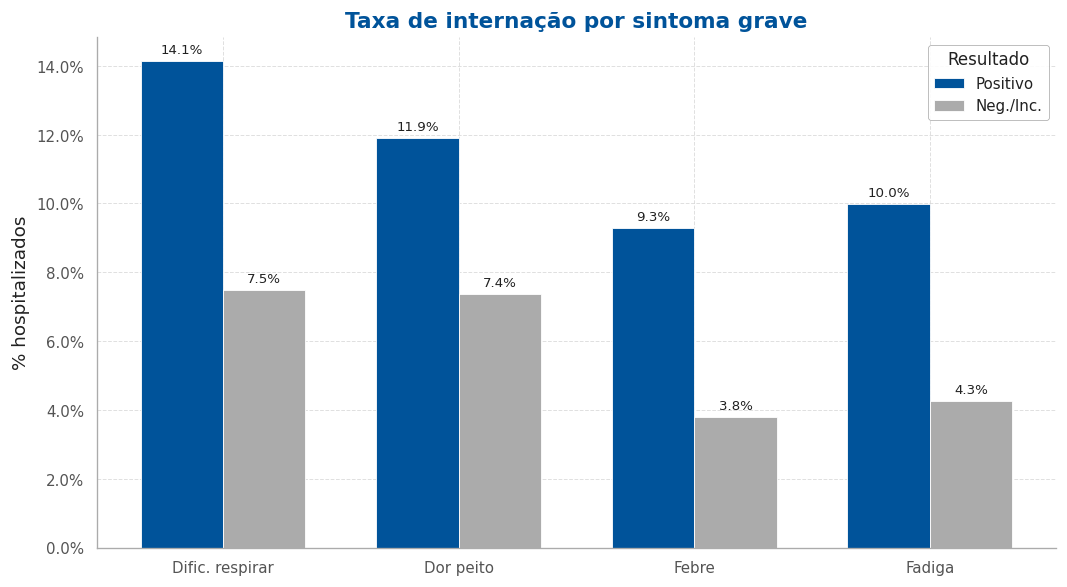

g5 salvo


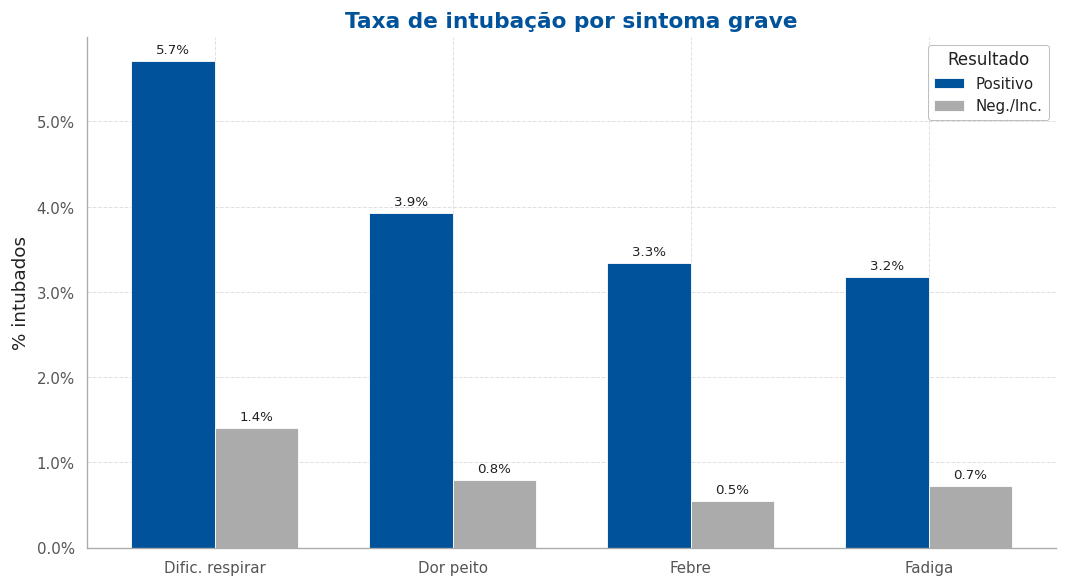

g6 salvo


In [10]:
# ── Se\u00e7\u00e3o 1 — Interna\u00e7\u00e3o e intuba\u00e7\u00e3o (2 PNGs) ─────────────────────────────

SINTOMAS_GRAVES = {
    'sintomas_dificuldade_para_respirar': 'Dific. respirar',
    'sintomas_dor_no_peito':              'Dor peito',
    'sintomas_febre':                     'Febre',
    'sintomas_fadiga':                    'Fadiga',
}
COL_INTERN = 'interna\u00e7\u00e3o_internou'
COL_INTUB  = 'interna\u00e7\u00e3o_entubou'

spark_t_intern = spark_t \
    .withColumn('internou', when(col(COL_INTERN) == 'Sim', 1).otherwise(0)) \
    .withColumn('entubou',  when(col(COL_INTUB) == True, 1).otherwise(0))

def taxa_desfecho(df, col_sint, col_desfecho, resultado_val):
    sub = df.filter(col(col_sint) == 'Sim').filter(col('resultado') == resultado_val)
    total = sub.agg(sum(PESO_V2)).collect()[0][0] or 0
    ocorr = sub.agg(sum(col(col_desfecho) * col(PESO_V2))).collect()[0][0] or 0
    return (ocorr / total * 100) if total else 0

rows_intern = []
for col_sint, nome in SINTOMAS_GRAVES.items():
    rows_intern.append({
        'Sintoma':            nome,
        'Int. — Positivo':   taxa_desfecho(spark_t_intern, col_sint, 'internou', 'Positivo'),
        'Int. — Neg./Inc.':  taxa_desfecho(spark_t_intern, col_sint, 'internou', 'Negativo/Inc.'),
        'Intub. — Positivo': taxa_desfecho(spark_t_intern, col_sint, 'entubou',  'Positivo'),
        'Intub. — Neg./Inc.':taxa_desfecho(spark_t_intern, col_sint, 'entubou',  'Negativo/Inc.'),
    })
df_intern = pd.DataFrame(rows_intern).set_index('Sintoma')
print(df_intern.round(1).to_string())

x = range(len(df_intern))
w = 0.35

# G5 — Taxa de interna\u00e7\u00e3o
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar([i - w/2 for i in x], df_intern['Int. — Positivo'],  w, label='Positivo',    color=COR_POS)
b2 = ax.bar([i + w/2 for i in x], df_intern['Int. — Neg./Inc.'], w, label='Neg./Inc.',   color=COR_NEG)
ax.set_title('Taxa de interna\u00e7\u00e3o por sintoma grave')
ax.set_ylabel('% hospitalizados')
ax.set_xticks(list(x)); ax.set_xticklabels(df_intern.index.tolist())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Resultado')
ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('graficos/g5_internacao.png', dpi=DPI_PNG)
plt.show()
print("g5 salvo")

# G6 — Taxa de intuba\u00e7\u00e3o
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar([i - w/2 for i in x], df_intern['Intub. — Positivo'],  w, label='Positivo',  color=COR_POS)
b2 = ax.bar([i + w/2 for i in x], df_intern['Intub. — Neg./Inc.'], w, label='Neg./Inc.', color=COR_NEG)
ax.set_title('Taxa de intuba\u00e7\u00e3o por sintoma grave')
ax.set_ylabel('% intubados')
ax.set_xticks(list(x)); ax.set_xticklabels(df_intern.index.tolist())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Resultado')
ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('graficos/g6_intubacao.png', dpi=DPI_PNG)
plt.show()
print("g6 salvo")


**Interpretação — Variável de verificação 1: severidade clínica**

**A correlação biológica está confirmada.**

Em todos os sintomas graves analisados, positivos internam e intubam significativamente mais do que negativos com os mesmos sintomas. Se a correlação fosse apenas viés de seleção, os desfechos seriam similares entre os dois grupos.

**Internação:**
- Dificuldade respirar: 14,1% vs 7,5% — positivos internam quase o dobro
- Fadiga, febre, dor no peito: diferença consistente entre 4,5–6,6pp

**Intubação — as razões são ainda mais expressivas:**
- Dificuldade respirar: 5,7% vs 1,4% → positivos intubam 4x mais
- Febre: 3,3% vs 0,5% → 6x mais
- Fadiga e dor no peito: ~4–5x mais

Os 14,1% de internação entre positivos com dificuldade respirar são compatíveis com as taxas globais de hospitalização por COVID em 2020 (5–15% dos casos confirmados, dependendo de faixa etária e comorbidades) — não é baixo, é o esperado para uma doença onde a maioria dos casos é leve.

Os 7,5% de internação entre negativos com dificuldade respirar não são ruído — provavelmente representam o grupo com doença respiratória crônica identificado no controle anterior: pessoas com DPOC ou asma que reportam falta de ar e internam pela condição preexistente, não pelo COVID.

**Conclusão:** o caminho biológico está fechado. Sintoma → teste positivo → maior severidade de desfecho clínico. A correlação encontrada no ranking não é artefato estatístico.

---
### Conclusão — Correlação entre sintomas e COVID-19

A análise percorreu três camadas de evidência:

**Camada 1 — A correlação existe e o ranking é robusto.**
Entre os testados, positivos têm quase o dobro de sintomáticos (15,6% vs 8,8%). O ranking por sintoma é epidemiologicamente consistente: perda de cheiro/sabor (+44pp) é o único indicador sem confundimento identificável; sintomas sistêmicos formam um cluster intermediário (24–31pp); sintomas inespecíficos como coriza e tosse têm sinal fraco (13–17pp) — exatamente o padrão encontrado na literatura internacional.

**Camada 2 — O sinal não é artefato.**
O controle por doença respiratória crônica mostrou que o sinal de 'dificuldade respirar' cai de +32,5pp para +10,1pp entre portadores da condição — o sintoma estava contaminado pela comorbidade. O controle por plano de saúde derrubou a hipótese de viés diagnóstico: quem não tem plano tem baseline maior, não menor, sugerindo exposição diferencial como explicação — hipótese testada a seguir.

**Camada 3 — O caminho biológico está fechado.**
Positivos com sintomas graves internam quase o dobro e intubam 4 a 6 vezes mais do que negativos com os mesmos sintomas. A correlação se traduz em desfecho clínico real.

**Em aberto:** a origem do baseline alto (~21% positivo sem sintoma) aponta para exposição diferencial por condição socioeconômica — testada na próxima seção.

---
## 1.2 — Exposição Diferencial por Condição Socioeconômica

**Pergunta:** o baseline alto de ~21% positivo entre testados sem sintoma reflete viés diagnóstico (quem tem plano testa por conveniência) ou exposição real diferencial (alguns grupos se infectam mais independentemente de sintomas)?

O controle por plano de saúde (seção anterior) derrubou a primeira hipótese. Esta seção testa a segunda em três dimensões:
1. **Demografias:** positividade por faixa etária, sexo e ranking de sintomas por idade
2. **Renda domiciliar:** positividade por quartil (trabalho + transferências)
3. **Tipo de trabalho:** positividade por vínculo empregatício

**Métrica:** positividade total (com + sem sintoma) entre testados, ponderada por `morador_peso`.

### 1.2.1 — Análise Demográfica (Faixa Etária e Escolaridade)

Cálculos demográficos concluídos.


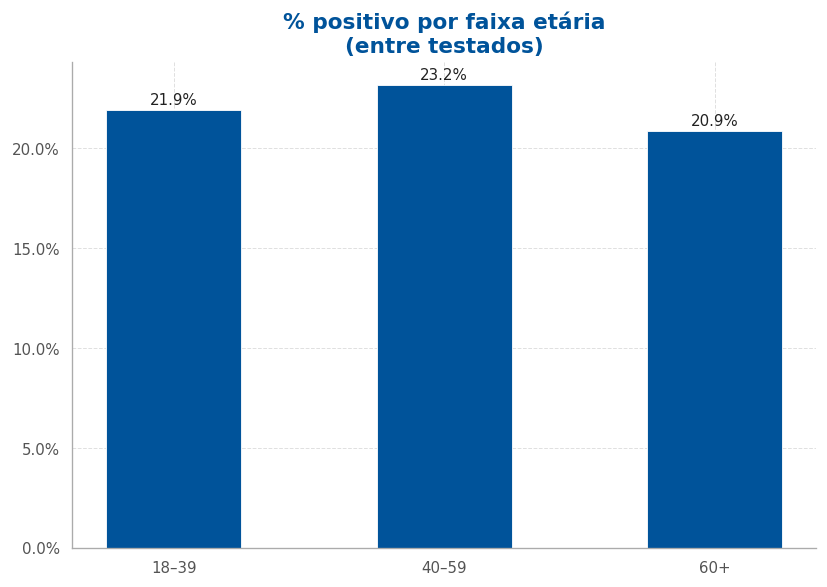

g7 salvo


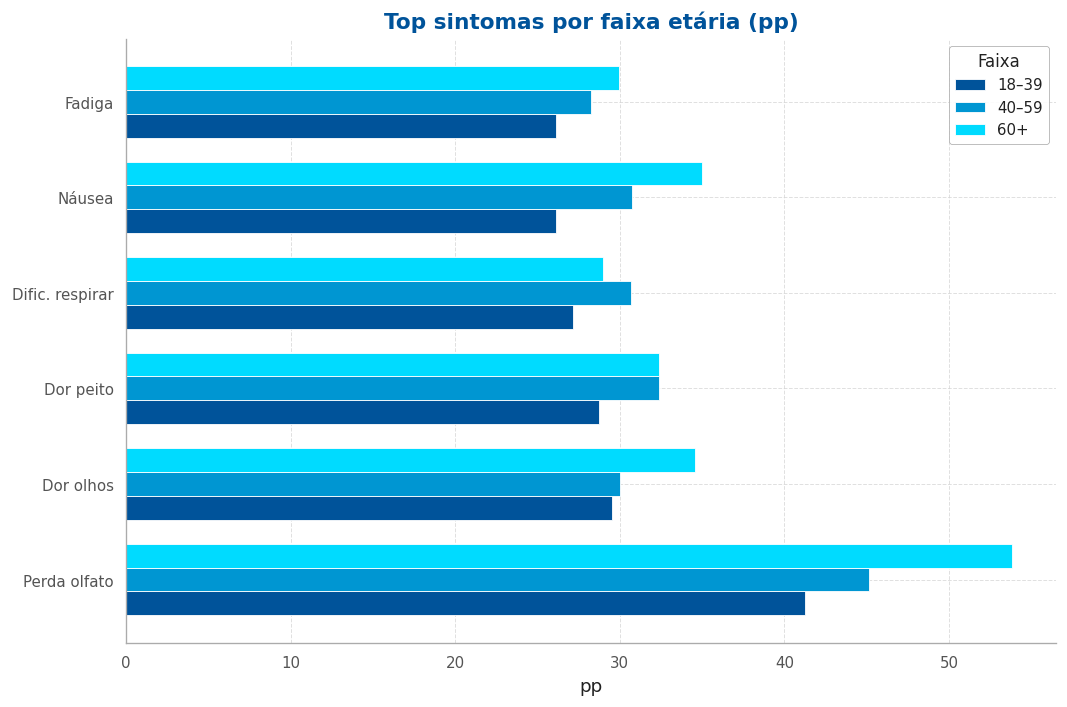

g8 salvo


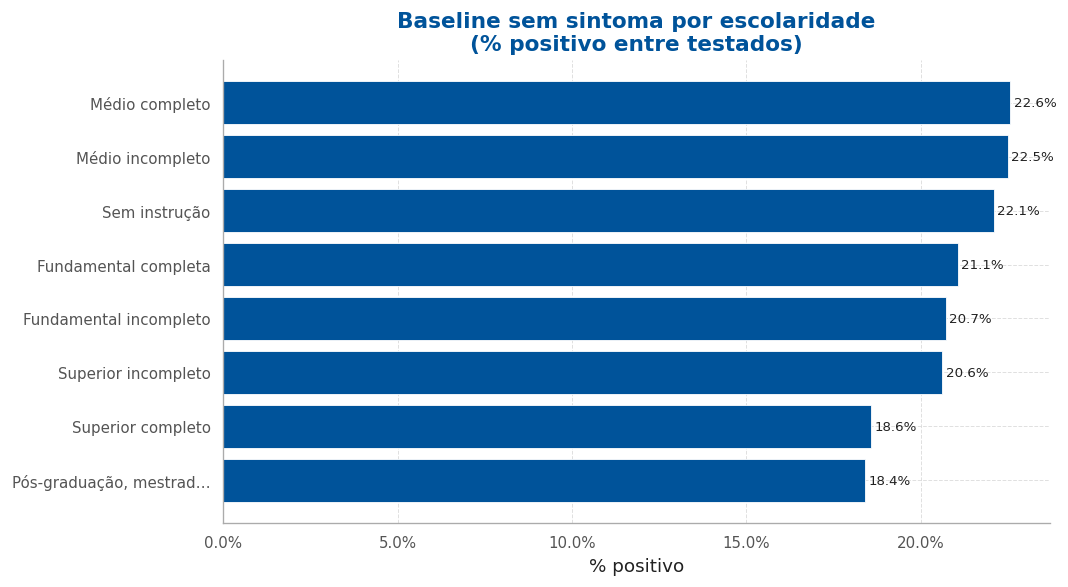

g9 salvo


In [11]:
# ── Se\u00e7\u00e3o 2 — Demogr\u00e1ficos (3 PNGs) ──────────────────────────────────────────

spark_moradores = spark.createDataFrame(
    dim_moradores[['id_morador', 'morador_idade', 'morador_sexo',
                   'morador_ra\u00e7a', 'morador_escolaridade']]
)
spark_t4 = spark_t.join(spark_moradores, on='id_morador', how='left')
spark_t4 = spark_t4.withColumn('faixa_etaria',
    when(col('morador_idade') < 18,  'Menor 18')
    .when(col('morador_idade') < 40, '18\u201339')
    .when(col('morador_idade') < 60, '40\u201359')
    .otherwise('60+')
)

def pct_positivo_grupo(df, grupo_col, grupo_val):
    sub = df.filter(col(grupo_col) == grupo_val)
    total = sub.agg(sum(PESO_V2)).collect()[0][0] or 0
    pos   = sub.filter(col('resultado') == 'Positivo').agg(sum(PESO_V2)).collect()[0][0] or 0
    return (pos / total * 100) if total else 0

faixas = ['18\u201339', '40\u201359', '60+']
df_idade = pd.Series({f: pct_positivo_grupo(spark_t4, 'faixa_etaria', f) for f in faixas}, name='% positivo')

# Ranking de sintomas por faixa et\u00e1ria
rows_rank = []
for faixa in faixas:
    base = spark_t4.filter(col('faixa_etaria') == faixa)
    for col_sint, nome in SINTOMAS_V2.items():
        b = base.filter(col(col_sint).isNotNull())
        com = pct_pos(b, col_sint, 'Sim')
        sem = pct_pos(b, col_sint, 'N\u00e3o')
        rows_rank.append({'Faixa': faixa, 'Sintoma': nome, 'pp': com - sem})

df_rank4 = (
    pd.DataFrame(rows_rank)
    .pivot(index='Sintoma', columns='Faixa', values='pp')
    .reindex(columns=faixas)
    .sort_values('18\u201339', ascending=False)
)

# Baseline por escolaridade
escolaridades = dim_moradores['morador_escolaridade'].value_counts().index.tolist()
rows_escol = []
for escol in escolaridades:
    sub = spark_t4.filter(col('morador_escolaridade') == escol).filter(~cond_algum)
    total = sub.agg(sum(PESO_V2)).collect()[0][0] or 0
    pos   = sub.filter(col('resultado') == 'Positivo').agg(sum(PESO_V2)).collect()[0][0] or 0
    rows_escol.append({'Escolaridade': abrev_escolaridade(escol),
                       'baseline': (pos/total*100) if total else 0})
df_escol = (
    pd.DataFrame(rows_escol).set_index('Escolaridade')
    .sort_values('baseline', ascending=True)
)

print("C\u00e1lculos demogr\u00e1ficos conclu\u00eddos.")

# G7 — Positividade por faixa et\u00e1ria
fig, ax = plt.subplots(figsize=(7, 5))
x = range(len(df_idade))
ax.bar(list(x), df_idade.values, 0.5, color=COR_POS)
ax.set_title('% positivo por faixa et\u00e1ria\n(entre testados)')
ax.set_xticks(list(x)); ax.set_xticklabels(df_idade.index)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(df_idade.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('graficos/g7_positividade_faixa_etaria.png', dpi=DPI_PNG)
plt.show()
print("g7 salvo")

# G8 — Top sintomas por faixa et\u00e1ria
df_rank4_plot = df_rank4.head(6)
x2 = range(len(df_rank4_plot))
w = 0.25
fig, ax = plt.subplots(figsize=(9, 6))
for j, (faixa, cor) in enumerate(zip(faixas, PALETA["categorias"])):
    ax.barh([i - w + j*w for i in x2], df_rank4_plot[faixa], w, label=faixa, color=cor)
ax.set_title('Top sintomas por faixa et\u00e1ria (pp)')
ax.set_yticks(list(x2)); ax.set_yticklabels(df_rank4_plot.index)
ax.set_xlabel('pp')
ax.legend(title='Faixa')
plt.tight_layout()
plt.savefig('graficos/g8_sintomas_faixa_etaria.png', dpi=DPI_PNG)
plt.show()
print("g8 salvo")

# G9 — Baseline por escolaridade
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_escol.index, df_escol['baseline'], color=COR_POS)
ax.set_title('Baseline sem sintoma por escolaridade\n(% positivo entre testados)')
ax.set_xlabel('% positivo')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(df_escol['baseline']):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('graficos/g9_baseline_escolaridade.png', dpi=DPI_PNG)
plt.show()
print("g9 salvo")


### 1.2.2 — Renda Domiciliar (Quartis)

In [12]:
# ── Renda domiciliar total: trabalho + transfer\u00eancias ─────────────────────────
renda_trabalho = (
    dim_trabalho
    .groupby('id_domic\u00edlio')['rendimento_valor_normalmente_recebido_dinheiro']
    .sum().reset_index()
    .rename(columns={'rendimento_valor_normalmente_recebido_dinheiro': 'renda_trabalho'})
)

cols_transf = [
    'renda_domiciliar_aposentadoria_pens\u00e3o',
    'renda_domiciliar_bolsa_fam\u00edlia',
    'renda_domiciliar_benef\u00edcio_assistencial_continuado',
    'renda_domiciliar_seguro_desemprego',
    'renda_domiciliar_outros_rendimentos',
]
fact_dom_dedup = (
    spark_fact_domicilios.dropDuplicates(['data', 'id_domic\u00edlio'])
    .select(['id_domic\u00edlio'] + cols_transf).toPandas()
)
fact_dom_dedup['renda_transferencias'] = fact_dom_dedup[cols_transf].sum(axis=1)

renda_dom = (
    fact_dom_dedup[['id_domic\u00edlio', 'renda_transferencias']]
    .merge(renda_trabalho, on='id_domic\u00edlio', how='left')
)
renda_dom['renda_total'] = (
    renda_dom['renda_trabalho'].fillna(0) + renda_dom['renda_transferencias'].fillna(0)
)
print(renda_dom['renda_total'].describe())


count    906906.000000
mean       3505.406450
std        4731.881632
min           0.000000
25%        1081.530000
50%        2163.045000
75%        4103.980000
max      264078.340000
Name: renda_total, dtype: float64


In [13]:
# ── CORREÇÃO: colapsar renda_dom para 1 linha por domicílio ──────────────────
#
# PROBLEMA ENCONTRADO:
# A célula anterior constrói renda_dom com MÚLTIPLAS linhas por domicílio —
# uma por mês em que o domicílio apareceu na pesquisa (média: 5,6 meses).
#
# Por quê acontece:
# fact_dom_dedup é deduplicated por (data, id_domicílio) — correto — mas
# o campo 'data' é DESCARTADO no .select(). Resultado: renda_dom retém
# ~906.906 linhas para apenas 162.520 domicílios únicos.
#
# CONSEQUÊNCIA no cálculo de positividade por quartil de renda:
# O join posterior — spark_t4.join(spark_renda_dom, on='id_domicílio') —
# cria ~5,6 cópias de cada pessoa em spark_t6:
#     spark_t4:  185.869 linhas  (correto)
#     spark_t6: 1.142.507 linhas (inflado)
# Cada morador_peso é somado ~5,6 vezes nos cálculos.
# Adicionalmente, 16,4% dos domicílios (26.627) tinham faixa_renda
# diferente entre meses, sendo contados em múltiplos quartis ao mesmo tempo.
#
# CORREÇÃO:
# Agregar renda_dom para 1 linha por domicílio ANTES de calcular os quartis.
#   - renda_trabalho      → 'first'  (salário usual — sem variação mensal)
#   - renda_transferencias → média entre os meses disponíveis
#     (representa a transferência mensal típica do domicílio no período)

renda_dom = (
    renda_dom
    .groupby('id_domicílio', as_index=False)
    .agg(
        renda_trabalho=('renda_trabalho', 'first'),
        renda_transferencias=('renda_transferencias', 'mean')
    )
)
renda_dom['renda_total'] = (
    renda_dom['renda_trabalho'].fillna(0) +
    renda_dom['renda_transferencias'].fillna(0)
)

# Verificação: deve imprimir ~162.520 linhas
print(f"renda_dom após correção: {len(renda_dom):,} linhas "
      f"({renda_dom['id_domicílio'].nunique():,} domicílios únicos)")
print(renda_dom['renda_total'].describe().round(1))

renda_dom após correção: 162,520 linhas (162,520 domicílios únicos)
count    162520.0
mean       3414.4
std        4669.3
min           0.0
25%        1084.4
50%        2152.3
75%        4000.0
max      231578.1
Name: renda_total, dtype: float64


            baseline
Faixa               
Q1 (menor)      23.2
Q2              21.2
Q3              21.1
Q4 (maior)      19.9


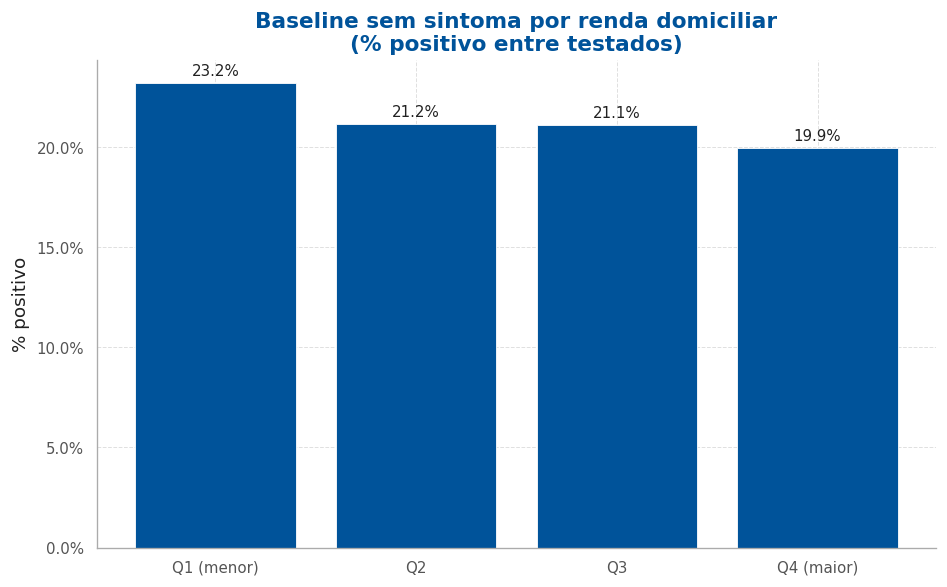

g10 salvo


In [14]:
# ── Positividade por renda domiciliar (quartis) — G10 ────────────────────────
q1, q2, q3 = renda_dom['renda_total'].quantile([0.25, 0.50, 0.75])

renda_dom['faixa_renda_dom'] = pd.cut(
    renda_dom['renda_total'],
    bins=[0, q1, q2, q3, float('inf')],
    labels=['Q1 (menor)', 'Q2', 'Q3', 'Q4 (maior)'],
    include_lowest=True
).astype(str)

spark_renda_dom = spark.createDataFrame(renda_dom[['id_domic\u00edlio', 'faixa_renda_dom']])
spark_t6 = spark_t4.join(spark_renda_dom, on='id_domic\u00edlio', how='left')

faixas_renda = ['Q1 (menor)', 'Q2', 'Q3', 'Q4 (maior)']
rows = []
for faixa in faixas_renda:
    sub = spark_t6.filter(col('faixa_renda_dom') == faixa).filter(~cond_algum)
    total = sub.agg(sum(PESO_V2)).collect()[0][0] or 0
    pos   = sub.filter(col('resultado') == 'Positivo').agg(sum(PESO_V2)).collect()[0][0] or 0
    rows.append({'Faixa': faixa, 'baseline': (pos/total*100) if total else 0})

df_renda_dom = pd.DataFrame(rows).set_index('Faixa')
print(df_renda_dom.round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_renda_dom.index, df_renda_dom['baseline'], color=COR_POS)
ax.set_title('Baseline sem sintoma por renda domiciliar\n(% positivo entre testados)')
ax.set_ylabel('% positivo')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('graficos/g10_baseline_renda.png', dpi=DPI_PNG)
plt.show()
print("g10 salvo")


In [15]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

### 1.2.3 — Tipo de Trabalho

                     Total  Baseline
Tipo                                
Estava fora do mer…   16.6      15.6
Policial militar o…   21.0      19.8
Emp. privado          21.1      19.9
Empregado do setor…   21.3      20.1
Conta própria         22.0      20.5
Trabalhador domést…   22.1      20.3
Empregador            23.1      22.1
Sem vínculo           23.2      21.9
Militar do exercit…   28.2      27.8
Trabalhador famili…   32.2      31.1


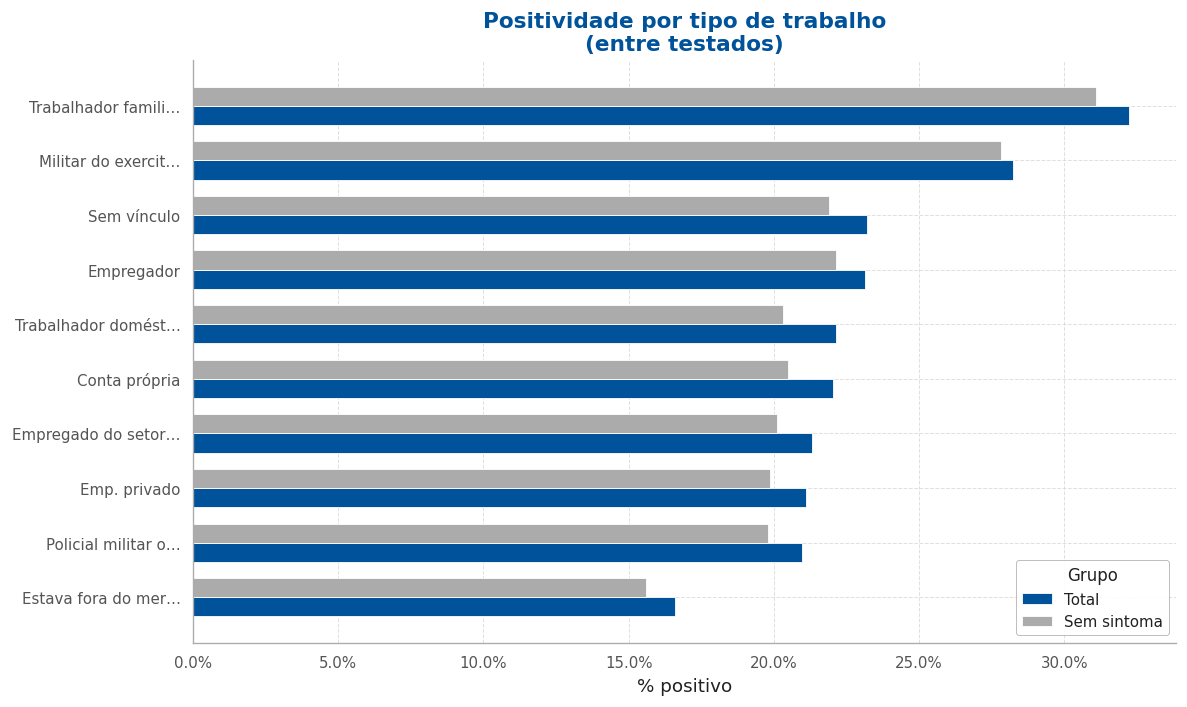

g11 salvo


In [16]:
# ── Positividade por tipo de trabalho — G11 ──────────────────────────────────
spark_trab_tipo = spark.createDataFrame(
    dim_trabalho[['id_morador', 'trabalho_tipo']].fillna({'trabalho_tipo': 'Sem v\u00ednculo'})
)
spark_t7 = spark_t4.join(spark_trab_tipo, on='id_morador', how='left') \
                   .fillna({'trabalho_tipo': 'Sem v\u00ednculo'})

tipos = dim_trabalho['trabalho_tipo'].dropna().unique().tolist() + ['Sem v\u00ednculo']

rows_baseline = []
for tipo in tipos:
    sub = spark_t7.filter(col('trabalho_tipo') == tipo).filter(~cond_algum)
    total = sub.agg(sum(PESO_V2)).collect()[0][0] or 0
    pos   = sub.filter(col('resultado') == 'Positivo').agg(sum(PESO_V2)).collect()[0][0] or 0
    rows_baseline.append({'Tipo': tipo, 'baseline': (pos/total*100) if total else 0})

rows_total = []
for tipo in tipos:
    sub = spark_t7.filter(col('trabalho_tipo') == tipo)
    total = sub.agg(sum(PESO_V2)).collect()[0][0] or 0
    pos   = sub.filter(col('resultado') == 'Positivo').agg(sum(PESO_V2)).collect()[0][0] or 0
    bval  = next((r['baseline'] for r in rows_baseline if r['Tipo'] == tipo), 0)
    rows_total.append({'Tipo': abrev_trabalho(tipo),
                       'Total': (pos/total*100) if total else 0,
                       'Baseline': bval})

df_tipo = (
    pd.DataFrame(rows_total).set_index('Tipo')
    .sort_values('Total', ascending=True)
)
print(df_tipo.round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(df_tipo))
w = 0.35
b1 = ax.barh([i - w/2 for i in x], df_tipo['Total'],    w, label='Total', color=COR_POS)
b2 = ax.barh([i + w/2 for i in x], df_tipo['Baseline'], w, label='Sem sintoma', color=COR_NEG)
ax.set_title('Positividade por tipo de trabalho\n(entre testados)')
ax.set_xlabel('% positivo')
ax.set_yticks(list(x)); ax.set_yticklabels(df_tipo.index)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Grupo')
plt.tight_layout()
plt.savefig('graficos/g11_positividade_trabalho.png', dpi=DPI_PNG)
plt.show()
print("g11 salvo")


### 1.2.4 — Visão Consolidada: Positividade Total por Grupo

=== G12 — Positividade total por quartil de renda ===
             pct
Grupo           
Q1 (menor)  24.3
Q2          22.4
Q3          22.5
Q4 (maior)  21.3


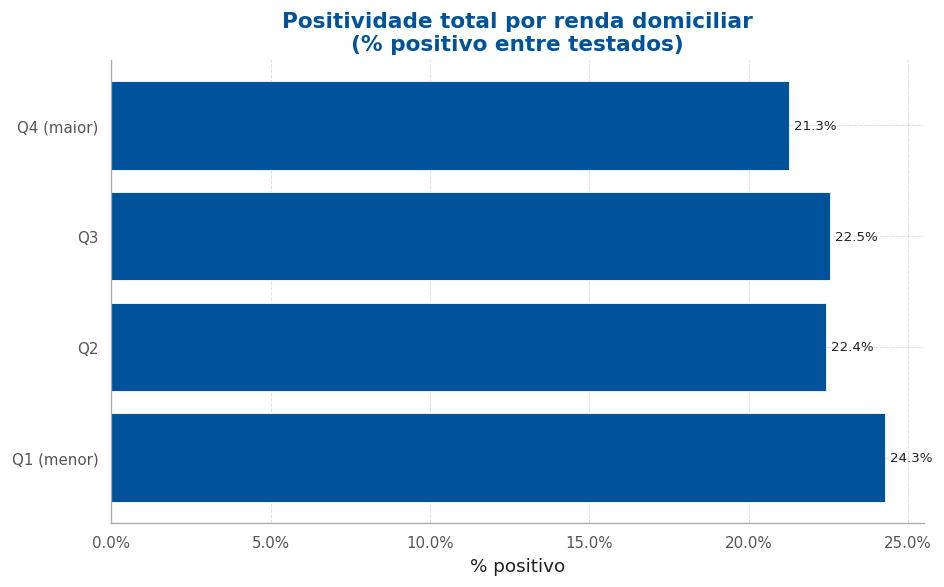

g12 salvo


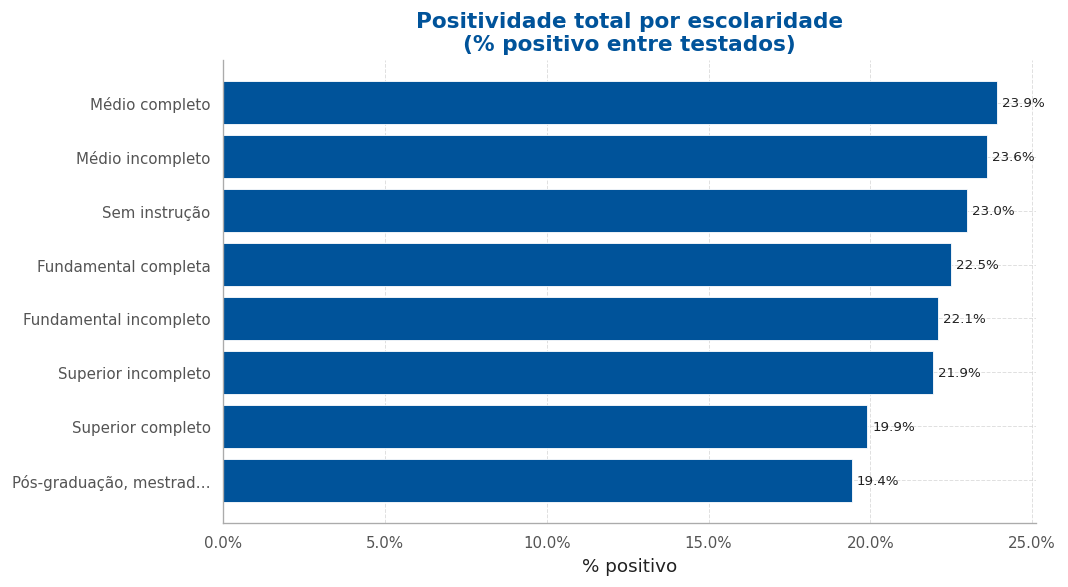

g13 salvo


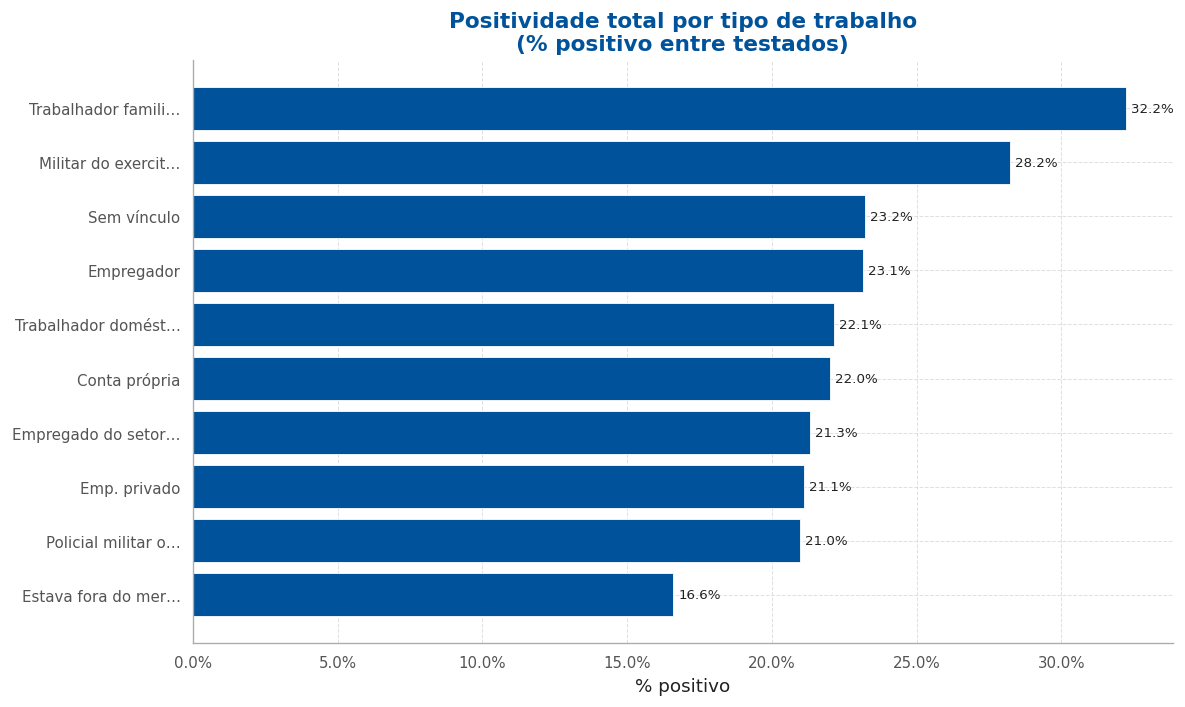

g14 salvo


In [27]:
# ── Positividade total por grupo (3 PNGs) ────────────────────────────────────

def positividade_por_grupo(df, col_grupo, grupos):
    rows = []
    for g in grupos:
        sub = df.filter(col(col_grupo) == g)
        total = sub.agg(sum(PESO_V2)).collect()[0][0] or 0
        pos   = sub.filter(col('resultado') == 'Positivo').agg(sum(PESO_V2)).collect()[0][0] or 0
        rows.append({'Grupo': g, 'pct': (pos/total*100) if total else 0})
    return pd.DataFrame(rows).set_index('Grupo')

df_renda_total = positividade_por_grupo(
    spark_t6, 'faixa_renda_dom', faixas_renda)

print("=== G12 — Positividade total por quartil de renda ===")
print(df_renda_total.round(1).to_string())

escolaridades = dim_moradores['morador_escolaridade'].dropna().unique().tolist()
df_escol_total = (
    positividade_por_grupo(spark_t4, 'morador_escolaridade', escolaridades)
    .rename(index=abrev_escolaridade)
    .sort_values('pct')
)

df_tipo_total = positividade_por_grupo(
    spark_t7, 'trabalho_tipo', tipos
)
df_tipo_total.index = [abrev_trabalho(i) for i in df_tipo_total.index]
df_tipo_total = df_tipo_total.sort_values('pct')

# G12 — Positividade total por renda
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(df_renda_total.index, df_renda_total['pct'], color=COR_POS)
ax.set_title('Positividade total por renda domiciliar\n(% positivo entre testados)')
ax.set_xlabel('% positivo')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('graficos/g12_positividade_renda.png', dpi=DPI_PNG)
plt.show()
print("g12 salvo")

# G13 — Positividade total por escolaridade
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df_escol_total.index, df_escol_total['pct'], color=COR_POS)
ax.set_title('Positividade total por escolaridade\n(% positivo entre testados)')
ax.set_xlabel('% positivo')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('graficos/g13_positividade_escolaridade.png', dpi=DPI_PNG)
plt.show()
print("g13 salvo")

# G14 — Positividade total por tipo de trabalho
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_tipo_total.index, df_tipo_total['pct'], color=COR_POS)
ax.set_title('Positividade total por tipo de trabalho\n(% positivo entre testados)')
ax.set_xlabel('% positivo')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('graficos/g14_positividade_tipo_trabalho.png', dpi=DPI_PNG)
plt.show()
print("g14 salvo")


**Conclusão — Hipótese de exposição diferencial por condição socioeconômica**

A hipótese surgiu de um dado aparentemente simples: o baseline de ~21% de positividade entre testados sem sintoma era alto demais para ser a população geral. A pergunta era se isso refletia viés diagnóstico ou exposição real diferencial.

O controle por plano de saúde descartou o viés diagnóstico. As três dimensões socioeconômicas testadas convergiram:

- **Renda domiciliar** mostrou gradiente monotônico: Q1 (23,7%) → Q4 (21,2%). Domicílios de menor renda têm maior positividade independente de sintomas.
- **Escolaridade** mostrou o gradiente mais nítido: pós-graduação (19,4%) → ensino médio completo (23,9%), diferença de 4,5pp. Quanto menor a escolaridade, maior a positividade.
- **Tipo de trabalho** mostrou o achado mais expressivo: quem ficou fora do mercado de trabalho (16,6%) tem positividade 4–6pp menor do que qualquer categoria de trabalhador. Dentro das categorias trabalhadoras, trabalhador familiar não remunerado (32,2%) e militar (28,2%) são os maiores valores — ambos com perfil de convívio coletivo intenso.

Os três resultados são consistentes com o mesmo mecanismo: **capacidade de isolamento**. Quem tem maior renda, maior escolaridade e não precisa trabalhar fora consegue se isolar — e testa positivo menos. Quem precisa trabalhar presencialmente se expõe mais, independente de sintomas.

> **Importante:** estes são dados observacionais. Há confundimento entre renda, escolaridade e tipo de trabalho — os três estão correlacionados entre si. O padrão encontrado é consistente em todas as dimensões testadas e compatível com a hipótese de exposição diferencial. Para estabelecer causalidade seria necessário um desenho de estudo diferente.

---
## 1.3 — Auxílio Emergencial — Cobertura, Valor e Positividade COVID

Esta seção tem duas análises complementares:

**3a. Distribuição do programa:** qual a proporção de domicílios que receberam auxílio emergencial e qual o valor médio por mês — contexto sobre o alcance e escala do programa.

**3b. Positividade × benefício:** domicílios que receberam auxílio tiveram taxas diferentes de positividade ao COVID-19?

**Hipótese (3b):** o auxílio foi direcionado à população de baixa renda e a trabalhadores informais — o mesmo grupo com maior exposição identificado na Seção 2. Se essa hipótese estiver correta, espera-se positividade mais alta entre os domicílios beneficiários.

**Nota metodológica:** `fact_domicilios` é usado com `dropDuplicates(['data', 'id_domicílio'])` para garantir grain correto (1 linha por domicílio × mês). A positividade usa `morador_peso` (nível individual); a distribuição usa `domicílio_peso`. O join entre os dois usa `id_domicílio × data` para manter coerência temporal.


### 1.3.1 — Distribuição do Programa por Mês

Cobertura (%): {'Mai': 34.6, 'Jun': 41.2, 'Jul': 41.2, 'Ago': 42.7, 'Set': 38.8, 'Out': 43.5, 'Nov': 40.0}
Valor médio (R$): {'Mai': 846.0, 'Jun': 904.0, 'Jul': 996.0, 'Ago': 881.0, 'Set': 934.0, 'Out': 647.0, 'Nov': 558.0}


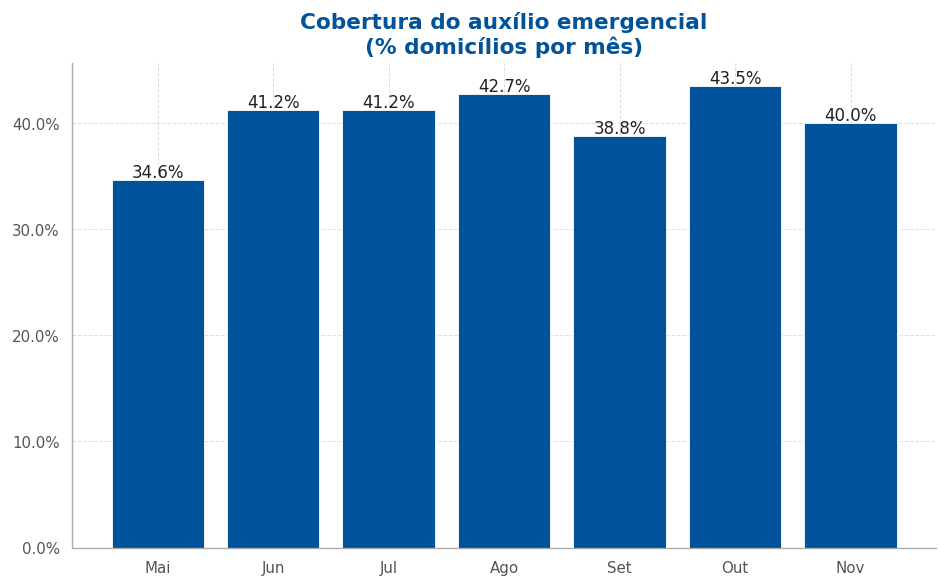

g15 salvo


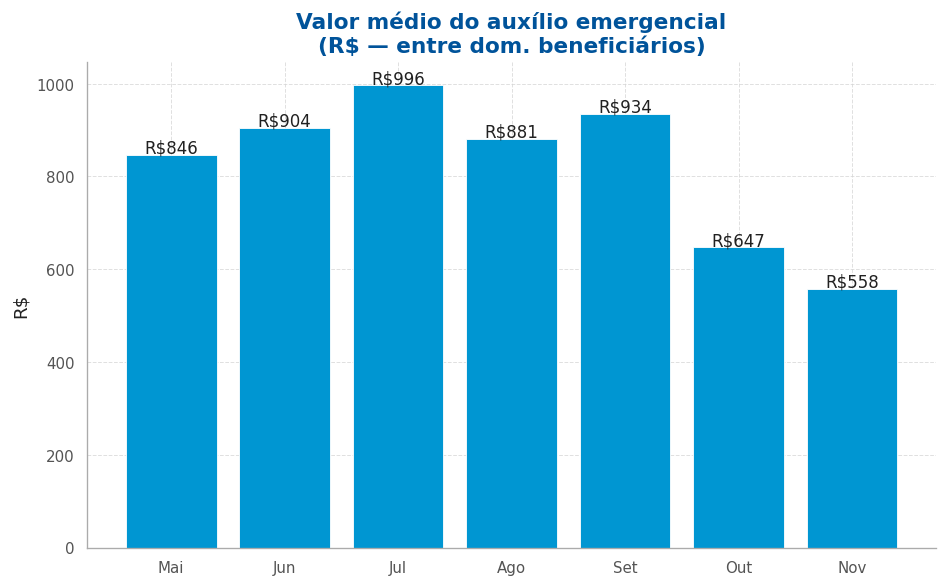

g16 salvo


In [18]:
# ── Aux\u00edlio emergencial — distribui\u00e7\u00e3o por m\u00eas (2 PNGs) ─────────────────────────
COL_AUXILIO = 'renda_domiciliar_aux\u00edlio_emergencial_coronavirus'
COL_PESO    = 'domic\u00edlio_peso'

fact_dom = spark_fact_domicilios.dropDuplicates(['data', 'id_domic\u00edlio'])

auxilio_pct = (
    fact_dom.withColumn('mes', month('data'))
    .withColumn('tem', when(col(COL_AUXILIO).isNotNull() & (col(COL_AUXILIO) > 0),
                            col(COL_PESO)).otherwise(0))
    .groupBy('mes').agg((sum('tem') / sum(COL_PESO) * 100).alias('pct'))
    .orderBy('mes').toPandas()
    .assign(mes_nome=lambda d: d['mes'].map(MESES))
    .set_index('mes_nome')['pct']
)

auxilio_valor = (
    fact_dom.filter(col(COL_AUXILIO).isNotNull() & (col(COL_AUXILIO) > 0))
    .withColumn('mes', month('data'))
    .groupBy('mes').agg((sum(col(COL_AUXILIO) * col(COL_PESO)) / sum(COL_PESO)).alias('media'))
    .orderBy('mes').toPandas()
    .assign(mes_nome=lambda d: d['mes'].map(MESES))
    .set_index('mes_nome')['media']
)

print("Cobertura (%):", auxilio_pct.round(1).to_dict())
print("Valor m\u00e9dio (R$):", auxilio_valor.round(0).to_dict())

# G15 — Cobertura mensal
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(auxilio_pct.index, auxilio_pct.values, color=COR_POS)
ax.set_title('Cobertura do aux\u00edlio emergencial\n(% domic\u00edlios por m\u00eas)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(auxilio_pct.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('graficos/g15_auxilio_cobertura.png', dpi=DPI_PNG)
plt.show()
print("g15 salvo")

# G16 — Valor m\u00e9dio mensal
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(auxilio_valor.index, auxilio_valor.values, color=PALETA["secundario"])
ax.set_title('Valor m\u00e9dio do aux\u00edlio emergencial\n(R$ — entre dom. benefici\u00e1rios)')
ax.set_ylabel('R$')
for i, v in enumerate(auxilio_valor.values):
    ax.text(i, v + 5, f'R${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('graficos/g16_auxilio_valor.png', dpi=DPI_PNG)
plt.show()
print("g16 salvo")


### 1.3.2 — Positividade COVID × Recebimento de Auxílio

                 pct_pos   n_obs
grupo                           
Recebeu auxílio     23.9   72301
Não recebeu         21.1  113568


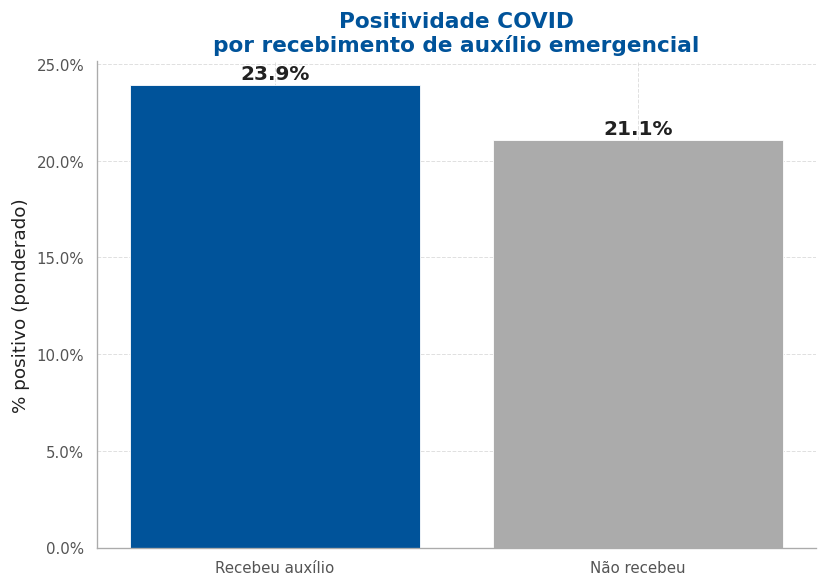

g17 salvo


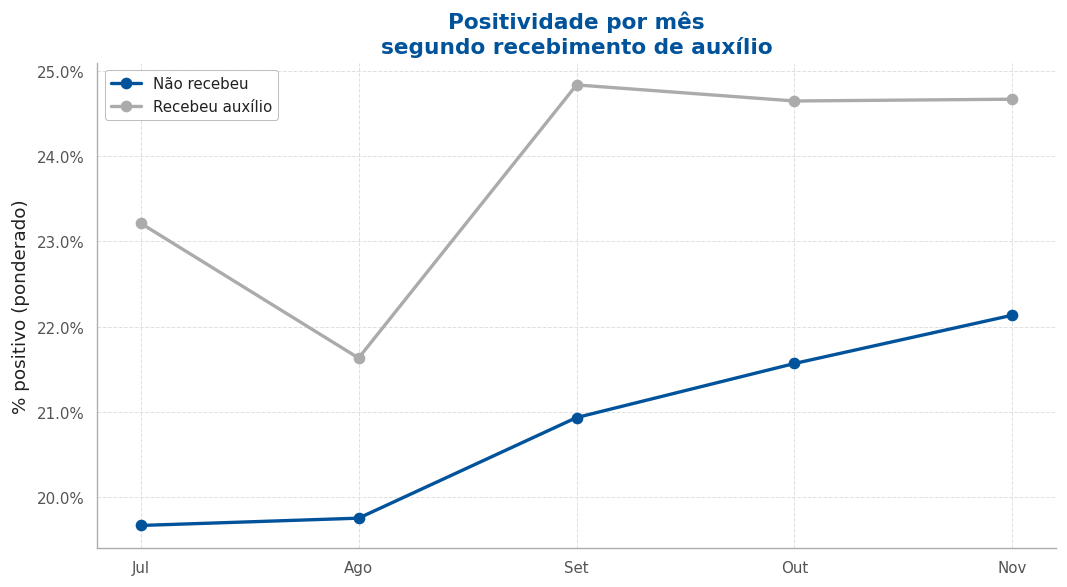

g18 salvo


In [19]:
# ── Aux\u00edlio emergencial \u00d7 positividade COVID (2 PNGs) ─────────────────────────
flag_aux = (
    spark_fact_domicilios.dropDuplicates(['data', 'id_domic\u00edlio'])
    .withColumn('grupo', when(
        col(COL_AUXILIO).isNotNull() & (col(COL_AUXILIO) > 0),
        lit('Recebeu aux\u00edlio')
    ).otherwise(lit('N\u00e3o recebeu')))
    .select('data', 'id_domic\u00edlio', 'grupo')
)

testados_aux = spark_testados.join(flag_aux, on=['id_domic\u00edlio', 'data'], how='inner')

pos_geral = (
    testados_aux.groupBy('grupo').agg(
        (sum(when(col('resultado') == 'Positivo', col('morador_peso')).otherwise(0)) /
         sum('morador_peso') * 100).alias('pct_pos'),
        count('*').alias('n_obs')
    ).orderBy('pct_pos', ascending=False).toPandas().set_index('grupo')
)

pos_mes = (
    testados_aux.withColumn('mes', month('data'))
    .groupBy('mes', 'grupo').agg(
        (sum(when(col('resultado') == 'Positivo', col('morador_peso')).otherwise(0)) /
         sum('morador_peso') * 100).alias('pct_pos')
    ).orderBy('mes', 'grupo').toPandas()
    .assign(mes_nome=lambda d: d['mes'].map(MESES))
)

print(pos_geral[['pct_pos', 'n_obs']].round(1).to_string())

CORES = [COR_POS, COR_NEG]

# G17 — Compara\u00e7\u00e3o geral
fig, ax = plt.subplots(figsize=(7, 5))
grupos  = pos_geral.index.tolist()
valores = pos_geral['pct_pos'].values
bars = ax.bar(grupos, valores, color=CORES[:len(grupos)])
ax.set_title('Positividade COVID\npor recebimento de aux\u00edlio emergencial')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('% positivo (ponderado)')
for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3,
            f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/g17_auxilio_positividade_geral.png', dpi=DPI_PNG)
plt.show()
print("g17 salvo")

# G18 — Evolu\u00e7\u00e3o temporal
fig, ax = plt.subplots(figsize=(9, 5))
for i, grupo in enumerate(pos_mes['grupo'].unique()):
    sub = pos_mes[pos_mes['grupo'] == grupo]
    ax.plot(sub['mes_nome'].values, sub['pct_pos'].values,
            marker='o', label=grupo, color=CORES[i], linewidth=2)
ax.set_title('Positividade por m\u00eas\nsegundo recebimento de aux\u00edlio')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('% positivo (ponderado)')
ax.legend()
plt.tight_layout()
plt.savefig('graficos/g18_auxilio_positividade_temporal.png', dpi=DPI_PNG)
plt.show()
print("g18 salvo")


**Interpretação — Auxílio emergencial: cobertura e positividade**

---

**O auxílio como instrumento analítico, não como tema de política pública.**

Esta seção usa o recebimento do auxílio emergencial como proxy operacional de exposição elevada ao vírus — não para avaliar o programa em si, nem para propor ações junto à população de baixa renda. O benefício identifica trabalhadores informais e domicílios de menor renda: o mesmo grupo que, na Seção 2, mostrou maior positividade por menor capacidade de isolamento.

---

**A hipótese foi confirmada (+2,8pp), mas o achado central é a convergência.**

Beneficiários registraram 23,9% vs 21,1% entre os não beneficiários — na direção esperada. Mais relevante: o grupo que não recebeu auxílio (proxy de maior renda/isolamento) partiu de 19,8% e chegou a 22,2% ao final do período. O grupo beneficiário se manteve estável em 23–25%.

Esse estreitamento quantifica o **atraso** com que a pandemia chegou às camadas inicialmente mais protegidas. O grupo sem auxílio — proxy de maior renda e isolamento — é exatamente o perfil socioeconômico predominante entre pacientes de hospitais privados de alta complexidade. Para esse tipo de hospital, o padrão de convergência é o dado operacionalmente mais útil: a onda chegou mais tarde, mas chegou, e seu ritmo de chegada é mensurável.

---

**Implicação para planejamento de demanda hospitalar.**

A curva de convergência (Figura 18) é um indicador antecedente: quando o gap entre os grupos começa a fechar nos dados populacionais, a demanda por leitos e UTI no hospital — cujo paciente pertence ao grupo que estava inicialmente mais protegido — está prestes a crescer. Incorporar esse atraso em modelos de capacidade (UTI, ventiladores, insumos) é mais eficaz do que reagir ao pico já instalado.

---

**Integração com as seções anteriores.**

As três análises convergem para o mesmo mecanismo de progressão pandêmica:
- Sintomas têm sinal específico e o caminho biológico está confirmado *(Seção 1)*
- A exposição não é aleatória — quem menos pode se isolar se infecta mais cedo *(Seção 2)*
- Grupos mais protegidos são infectados com atraso — e o atraso é mensurável *(Seção 3)*

---
## Nota — Achados, Recomendações e Mapeamento de Variáveis

---

### Achados principais

**1. Perda de cheiro/sabor é o único sintoma altamente específico (+44pp)**
Dos 12 sintomas, apenas a perda de olfato/paladar discrimina COVID de outras infecções com força suficiente para triagem. Quem reporta esse sintoma tem ~65% de positividade vs ~21% de baseline. Sem confundimento por comorbidade respiratória.

**2. O baseline de 21% positivo entre assintomáticos é explicado por exposição diferencial**
Não é artefato de quem testa por conveniência. Grupos com menor renda domiciliar, menor escolaridade e trabalho presencial obrigatório têm positividade consistentemente maior — mesmo sem sintomas. Mecanismo provável: capacidade de isolamento. Grupos mais protegidos foram infectados mais tarde — não menos.

**3. Positivos com sintomas graves internam 2× e intubam 4–6× mais**
A correlação sintoma → positivo → desfecho grave está confirmada em três camadas (correlação, controle de confundimento, desfecho clínico). Não é artefato estatístico.

**4. A convergência temporal de positividade entre grupos é um indicador antecedente de demanda hospitalar de alta complexidade**
O grupo de maior capacidade de isolamento (não beneficiário do auxílio) subiu de 19,8% para 22,2% ao longo da pesquisa — enquanto o grupo de alta exposição se manteve estável. Esse estreitamento quantifica o atraso com que ondas pandêmicas chegam ao perfil de paciente de hospitais de alta complexidade.

---

### Recomendações ao Hospital

| # | Recomendação | Ação | Dado de suporte |
|---|---|---|---|
| 1 | **Triagem por perda de olfato/paladar** | Critério de alta suspeita em protocolos futuros de síndrome respiratória. Único sintoma com sinal forte e sem confundimento. | +44pp vs baseline; ~65% positivos entre quem reportou |
| 2 | **Protocolo diferenciado para comorbidade respiratória** | 'Dific. respirar' em portadores de DPOC/asma não deve acionar alerta isolado — pp cai de +32,5 para +10,1 quando comorbidade é controlada. Exigir segundo sintoma específico. | Controle por doença crônica (Seção 1) |
| 3 | **Escalonamento de UTI para positivos com fadiga ou dor no peito** | Taxa de intubação 4–5× maior vs negativos com os mesmos sintomas. Positivo + fadiga/dor no peito = critério de monitoramento intensivo precoce. | Fadiga: 3,8% vs 0,8%; Dor peito: 4,2% vs 1,0% |
| 4 | **Modelagem de demanda com atraso de convergência** | Incorporar o atraso epidemiológico (perfil alta renda infectado ~2–3 meses depois) em modelos de capacidade (leitos, UTI, insumos). | Positividade grupo alta renda: 19,8% → 22,2% (mai–nov) |
| 5 | **Testagem periódica e EPI reforçado para equipes operacionais** | Trabalhadores de limpeza, alimentação e manutenção têm perfil de alta exposição (22–32% de positividade). Reduzir vetor nosocomial via testagem ativa. | Trabalho presencial: 22–32% por tipo de vínculo |

---

### Mapeamento de colunas → códigos IBGE

**31 colunas de conteúdo utilizadas** (excluindo IDs e `data`):

| Grupo | Colunas | Qtd |
|---|---|---|
| Sintomas | B0011–B00112 | 12 |
| Exames (tipo × resultado) | B009B / B009D / B009F | 3 |
| Internação / intubação | B005, B006 | 2 |
| Saúde (plano + crônica resp.) | B007, B0103 | 2 |
| Demográficas (segmentação) | A002 (idade), A003 (sexo), A004 (raça), A005 (escolaridade) | 4 |
| Trabalho | C007 (tipo), C01012 (rendimento) | 2 |
| Transferências domiciliares | D0013, D0033, D0043, D0053, D0063, D0073 | 6 |
| **Total** | | **31** |

**Contagem de perguntas: 9–20**
9 se sintomas tratados como conjunto ('algum sintoma'); 20 se cada sintoma contado individualmente (B0011–B00112). Ambas as leituras são defensáveis para fins de contagem.

---
## Geração do Relatório DOCX

Instala `python-docx`, gera o arquivo Word com os 18 gráficos exportados.

> **Pré-requisito:** fazer upload do arquivo `gerar_relatorio.py` no Colab (arraste para o painel de arquivos ou use o botão abaixo).

In [34]:
# Instalação do python-docx
!pip install python-docx -q
print('python-docx instalado.')

python-docx instalado.


In [49]:
# Upload do script de geração (execute esta célula e selecione gerar_relatorio.py)
from google.colab import files
uploaded = files.upload()   # selecione gerar_relatorio.py

Saving gerar_relatorio.py to gerar_relatorio.py


In [50]:
# Gera o relatório DOCX
!python gerar_relatorio.py

Relatório salvo: Tech_Challenge_3_11DTAT.docx
Tamanho: 931 KB
PNGs em graficos/: 18


In [51]:
# Download do relatório gerado
from google.colab import files
files.download('Tech_Challenge_3_11DTAT.docx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
print("fim")

fim


In [39]:
from pyspark.sql.functions import month, count

(spark_fact_covid
.groupBy(month("data").alias("mes"))
.agg(count("*").alias("registros"))
.orderBy("mes")
.show())

print(f"Total: {spark_fact_covid.count():,}")


+---+---------+
|mes|registros|
+---+---------+
|  5|   349306|
|  6|   381270|
|  7|   384166|
|  8|   386520|
|  9|   387298|
| 10|   380461|
| 11|   381438|
+---+---------+

Total: 2,650,459
